<a href="https://colab.research.google.com/github/shelarumesh/Integrated-Retail-Analytics-for-Store-Optimization-and-Demand-Forecasting/blob/main/EDAML_Anomalies_Clstaring_MarketAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Name**    - Integrated Retail Analytics for Store Optimization and Demand Forecasting



##### **Project Type**    - EDA/Regression/Classification/Unsupervised
##### **Contribution**    - Individual
##### **Presented By** - MR.UMESH PRAKASH SHELAR

# **Project Summary -**

1. Data Cleaning and Anomaly Detection
The first phase involves a deep dive into sales patterns to identify "outliers." By investigating the causes of these anomalies—such as regional holidays or specific markdown events—we ensure the data used for modeling is clean and representative of true trends. We also tackle the challenge of missing "MarkDown" data, using feature engineering to fill gaps and create new variables like store size and regional factors.

2. Demand Forecasting and Time-Series Analysis
Using advanced time-series models, the project forecasts weekly sales. These models are not just based on historical numbers; they incorporate dynamic features like the unemployment rate and fuel prices. This allows the retailer to look ahead and prepare for seasonal variations, ensuring that high-demand periods are met with adequate stock levels.

3. Store Segmentation and Market Basket Inference
Not all stores perform equally. We use clustering techniques to group stores and departments with similar sales patterns. While individual transaction data is limited, we use sales trends to infer Market Basket associations. This helps in developing cross-selling strategies and tailored inventory management plans for each specific segment.



# **GitHub Link -**

GIT HUB LINK : https://github.com/shelarumesh/Integrated-Retail-Analytics-for-Store-Optimization-and-Demand-Forecasting

# **Problem Statement**


Retailers today operate in a high-stakes environment where even small errors in inventory or pricing can lead to massive financial losses. The industry faces three primary challenges:

Data Noise and Anomalies: Sales data is often "noisy" due to sudden holidays, economic shifts, or data entry errors. Without identifying these anomalies, forecasting becomes inaccurate.

Unpredictable External Factors: Retail performance is not just about what happens inside the store. External indicators like the Consumer Price Index (CPI), unemployment rates, and fuel prices significantly impact consumer spending power.

One-Size-Fits-All Strategies: Many retailers treat all stores and departments the same. Without proper Customer and Store Segmentation, marketing efforts are wasted, and inventory is often mismanaged—leading to either overstocking or empty shelves.

#### **Define Your Business Objective?**

The primary objective of this project is to build an end-to-end analytical framework that optimizes store performance and forecasts future demand. Specifically, we aim to:

Clean and preprocess complex retail datasets to handle missing values and "MarkDown" noise.

Develop robust Demand Forecasting models to predict weekly sales for individual stores and departments.

Segment stores based on performance and regional characteristics to create Personalized Marketing and inventory strategies.

Quantify the impact of external economic and climatic factors on retail sales.

# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [ ]:
pip install mlxtend

In [ ]:
pip install statsmodels

In [2]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from scipy import stats
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)


### Dataset Loading

In [3]:
# Drive path where dataset available
Features_data = 'D:\AlmaBetter\Integrated-Retail-Analytics-for-Store-Optimization-and-Demand-Forecasting\data\Features data set.csv'
Sale_data = 'D:\AlmaBetter\Integrated-Retail-Analytics-for-Store-Optimization-and-Demand-Forecasting\data\sales data-set.csv'
store_data = 'D:\AlmaBetter\Integrated-Retail-Analytics-for-Store-Optimization-and-Demand-Forecasting\data\stores data-set.csv'

<>:2: SyntaxWarning: invalid escape sequence '\A'
<>:3: SyntaxWarning: invalid escape sequence '\A'
<>:4: SyntaxWarning: invalid escape sequence '\A'
<>:2: SyntaxWarning: invalid escape sequence '\A'
<>:3: SyntaxWarning: invalid escape sequence '\A'
<>:4: SyntaxWarning: invalid escape sequence '\A'
C:\Users\shela\AppData\Local\Temp\ipykernel_17252\1702896292.py:2: SyntaxWarning: invalid escape sequence '\A'
  Features_data = 'D:\AlmaBetter\Integrated-Retail-Analytics-for-Store-Optimization-and-Demand-Forecasting\data\Features data set.csv'
C:\Users\shela\AppData\Local\Temp\ipykernel_17252\1702896292.py:3: SyntaxWarning: invalid escape sequence '\A'
  Sale_data = 'D:\AlmaBetter\Integrated-Retail-Analytics-for-Store-Optimization-and-Demand-Forecasting\data\sales data-set.csv'
C:\Users\shela\AppData\Local\Temp\ipykernel_17252\1702896292.py:4: SyntaxWarning: invalid escape sequence '\A'
  store_data = 'D:\AlmaBetter\Integrated-Retail-Analytics-for-Store-Optimization-and-Demand-Forecasting\

In [4]:
# Load Dataset
Features_data_df = pd.read_csv(Features_data)
Sale_data_df = pd.read_csv(Sale_data)
store_data_df = pd.read_csv(store_data)

### Dataset First View

In [5]:
# Dataset First Look
Sale_data_df.head()


,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,05/02/2010,24924.50,False
1,1,1,12/02/2010,46039.49,True
2,1,1,19/02/2010,41595.55,False
3,1,1,26/02/2010,19403.54,False
4,1,1,05/03/2010,21827.90,False


In [6]:
Features_data_df.head()


,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,05/02/2010,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,12/02/2010,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,19/02/2010,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,26/02/2010,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,05/03/2010,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False


In [7]:
store_data_df.head()

,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875


### Dataset Rows & Columns count

In [8]:
# Dataset Rows & Columns count
print(f"Features_data_df : Rows -- {Features_data_df.shape[0]} Column-- {Features_data_df.shape[1]}")
print(f"Sale_data_df: Rows -- {Sale_data_df.shape[0]} Column -- {Sale_data_df.shape[1]}")
print(f"store_data_df: Rows -- {store_data_df.shape[0]} Column -- {store_data_df.shape[1]}")

Features_data_df : Rows -- 8190 Column-- 12
Sale_data_df: Rows -- 421570 Column -- 5
store_data_df: Rows -- 45 Column -- 3


### Dataset Information

In [9]:
df = pd.merge(Sale_data_df, Features_data_df, on=['Store', 'Date', 'IsHoliday'], how='left')
df = pd.merge(df, store_data_df, on=['Store'], how='left')

print("Merged DataFrame Head:")
print(df.head())
print("\nMerged DataFrame Shape:")
print(df.shape)


Merged DataFrame Head:
   Store  Dept        Date  Weekly_Sales  IsHoliday  Temperature  Fuel_Price  \
0      1     1  05/02/2010      24924.50      False        42.31       2.572   
1      1     1  12/02/2010      46039.49       True        38.51       2.548   
2      1     1  19/02/2010      41595.55      False        39.93       2.514   
3      1     1  26/02/2010      19403.54      False        46.63       2.561   
4      1     1  05/03/2010      21827.90      False        46.50       2.625   

   MarkDown1  MarkDown2  MarkDown3  MarkDown4  MarkDown5         CPI  \
0        NaN        NaN        NaN        NaN        NaN  211.096358   
1        NaN        NaN        NaN        NaN        NaN  211.242170   
2        NaN        NaN        NaN        NaN        NaN  211.289143   
3        NaN        NaN        NaN        NaN        NaN  211.319643   
4        NaN        NaN        NaN        NaN        NaN  211.350143   

   Unemployment Type    Size  
0         8.106    A  151315  
1

In [10]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Date          421570 non-null  object 
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday     421570 non-null  bool   
 5   Temperature   421570 non-null  float64
 6   Fuel_Price    421570 non-null  float64
 7   MarkDown1     150681 non-null  float64
 8   MarkDown2     111248 non-null  float64
 9   MarkDown3     137091 non-null  float64
 10  MarkDown4     134967 non-null  float64
 11  MarkDown5     151432 non-null  float64
 12  CPI           421570 non-null  float64
 13  Unemployment  421570 non-null  float64
 14  Type          421570 non-null  object 
 15  Size          421570 non-null  int64  
dtypes: bool(1), float64(10), int64(3), object(2)
memory usage: 48.6+ MB


#### Duplicate Values

In [11]:
# Dataset Duplicate Value Count
df[df.duplicated()]

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size


In [12]:
# print the dataset which are duplicated
print("Duplicate data is : ",df[df.duplicated()].count())

Duplicate data is :  Store           0
Dept            0
Date            0
Weekly_Sales    0
IsHoliday       0
Temperature     0
Fuel_Price      0
MarkDown1       0
MarkDown2       0
MarkDown3       0
MarkDown4       0
MarkDown5       0
CPI             0
Unemployment    0
Type            0
Size            0
dtype: int64


#### Missing Values/Null Values

In [13]:
# Missing Values/Null Values Count
df.isnull().sum()/len(df)*100

Store            0.000000
Dept             0.000000
Date             0.000000
Weekly_Sales     0.000000
IsHoliday        0.000000
Temperature      0.000000
Fuel_Price       0.000000
MarkDown1       64.257181
MarkDown2       73.611025
MarkDown3       67.480845
MarkDown4       67.984676
MarkDown5       64.079038
CPI              0.000000
Unemployment     0.000000
Type             0.000000
Size             0.000000
dtype: float64

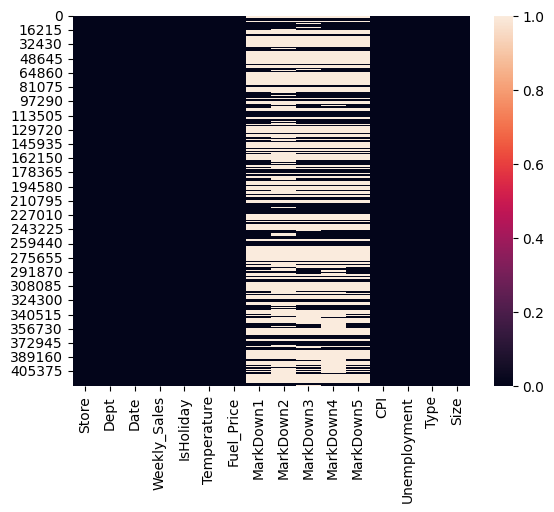

In [14]:
# Visualizing the missing values
sns.heatmap(df.isnull())
plt.show()

### What did you know about your dataset?

- This insurance dataset observed following things
    1. There are 421570 row and 16 columns
    2. Data set has null values
    3. Missing values in markdown columns is greater than 50 %.

## ***2. Understanding Your Variables***

In [18]:
# Dataset Columns
df.columns

Index(['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday', 'Temperature',
       'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4',
       'MarkDown5', 'CPI', 'Unemployment', 'Type', 'Size'],
      dtype='object')

In [19]:
# Dataset Describe
df.describe()

,Store,Dept,Weekly_Sales,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Size
count,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,150681.000000,111248.000000,137091.000000,134967.000000,151432.000000,421570.000000,421570.000000,421570.000000
mean,22.200546,44.260317,15981.258123,60.090059,3.361027,7246.420196,3334.628621,1439.421384,3383.168256,4628.975079,171.201947,7.960289,136727.915739
std,12.785297,30.492054,22711.183519,18.447931,0.458515,8291.221345,9475.357325,9623.078290,6292.384031,5962.887455,39.159276,1.863296,60980.583328
min,1.000000,1.000000,-4988.940000,-2.060000,2.472000,0.270000,-265.760000,-29.100000,0.220000,135.160000,126.064000,3.879000,34875.000000
25%,11.000000,18.000000,2079.650000,46.680000,2.933000,2240.270000,41.600000,5.080000,504.220000,1878.440000,132.022667,6.891000,93638.000000
50%,22.000000,37.000000,7612.030000,62.090000,3.452000,5347.450000,192.000000,24.600000,1481.310000,3359.450000,182.318780,7.866000,140167.000000
75%,33.000000,74.000000,20205.852500,74.280000,3.738000,9210.900000,1926.940000,103.990000,3595.040000,5563.800000,212.416993,8.572000,202505.000000
max,45.000000,99.000000,693099.360000,100.140000,4.468000,88646.760000,104519.540000,141630.610000,67474.850000,108519.280000,227.232807,14.313000,219622.000000


### Variables Description

### Check Unique Values for each variable.

In [20]:
# Check Unique Values for each variable.
for col in df.columns:
  data = df[col].unique()
  print(col , " unique data is : ", len(data))

Store  unique data is :  45
Dept  unique data is :  81
Date  unique data is :  143
Weekly_Sales  unique data is :  359464
IsHoliday  unique data is :  2
Temperature  unique data is :  3528
Fuel_Price  unique data is :  892
MarkDown1  unique data is :  2278
MarkDown2  unique data is :  1500
MarkDown3  unique data is :  1663
MarkDown4  unique data is :  1945
MarkDown5  unique data is :  2294
CPI  unique data is :  2145
Unemployment  unique data is :  349
Type  unique data is :  3
Size  unique data is :  40


## 3. ***Data Wrangling***

### Data Wrangling Code

In [21]:
# Write your code to make your dataset analysis ready.
# Convert date into datetime format
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day

In [22]:
# Count the total rows which has negative sales
len(df[df['Weekly_Sales']<0])

1285

In [23]:
# Weekly sales must be in positive number
df = df[df['Weekly_Sales'] > 0]
print(f"Total rows of the dataset are : {len(df)} and \n columns are {df.columns}")

Total rows of the dataset are : 420212 and 
 columns are Index(['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday', 'Temperature',
       'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4',
       'MarkDown5', 'CPI', 'Unemployment', 'Type', 'Size', 'Year', 'Month',
       'Day'],
      dtype='object')


In [24]:
# check null valus after droping data points from weekly sales
df.isnull().sum()/len(df)*100

Store            0.000000
Dept             0.000000
Date             0.000000
Weekly_Sales     0.000000
IsHoliday        0.000000
Temperature      0.000000
Fuel_Price       0.000000
MarkDown1       64.260659
MarkDown2       73.607608
MarkDown3       67.480462
MarkDown4       67.988063
MarkDown5       64.082654
CPI              0.000000
Unemployment     0.000000
Type             0.000000
Size             0.000000
Year             0.000000
Month            0.000000
Day              0.000000
dtype: float64

In [25]:
# Create new features base on the size of the store
def new_size(size_value):
  if size_value < 50000:
    return 'Small'
  elif size_value < 100000:
    return 'Medium'
  else:
    return 'Large'
df['Size_type'] = df['Size'].apply(new_size)
df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size,Year,Month,Day,Size_type
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,A,151315,2010,2,5,Large
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,A,151315,2010,2,12,Large
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,A,151315,2010,2,19,Large
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,A,151315,2010,2,26,Large
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,A,151315,2010,3,5,Large


In [26]:
df['Size_type'].value_counts()

Size_type
Large     308692
Small      73143
Medium     38377
Name: count, dtype: int64

In [27]:
# Create new features base on the size of the store
def sales_type(size_value):
  if size_value < 250000:
    return '0-2.5 L'
  elif size_value < 500000:
    return '2.5-5 L'
  else:
    return 'above 5 L'
df['Sales_Type'] = df['Weekly_Sales'].apply(sales_type)
df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,...,MarkDown5,CPI,Unemployment,Type,Size,Year,Month,Day,Size_type,Sales_Type
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,...,NaN,211.096358,8.106,A,151315,2010,2,5,Large,0-2.5 L
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,...,NaN,211.242170,8.106,A,151315,2010,2,12,Large,0-2.5 L
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,...,NaN,211.289143,8.106,A,151315,2010,2,19,Large,0-2.5 L
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,...,NaN,211.319643,8.106,A,151315,2010,2,26,Large,0-2.5 L
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,...,NaN,211.350143,8.106,A,151315,2010,3,5,Large,0-2.5 L


In [28]:
df['Sales_Type'].value_counts()

Sales_Type
0-2.5 L      420150
2.5-5 L          58
above 5 L         4
Name: count, dtype: int64

#### Missing data and its distribution

In [29]:
df[[ 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4',
       'MarkDown5']].describe()

,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5
count,150181.000000,110904.000000,136651.000000,134518.000000,150929.000000
mean,7247.821269,3330.146158,1441.736203,3384.782267,4629.531870
std,8293.028741,9460.395025,9631.968459,6295.136952,5960.171711
min,0.270000,-265.760000,-29.100000,0.220000,135.160000
25%,2240.270000,41.600000,5.100000,504.220000,1878.440000
50%,5347.450000,192.000000,24.600000,1481.310000,3359.450000
75%,9210.900000,1926.940000,103.990000,3595.040000,5563.800000
max,88646.760000,104519.540000,141630.610000,67474.850000,108519.280000


In [30]:
# Drop all Markdown columns because of more than 50 %null data exist
df_new = df[['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Type', 'Size', 'Year', 'Month', 'Day']]

### What all manipulations have you done and insights you found?

- Date columns data type change and created more columns to get mre information abou time series data analysis.
- New columns transformation steps completed with size and weekly sales and created new columns which give the information of the dataset values in columns and its types.
- Delete the columns whch name as Markdown becaused it has null data more than 60 %

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

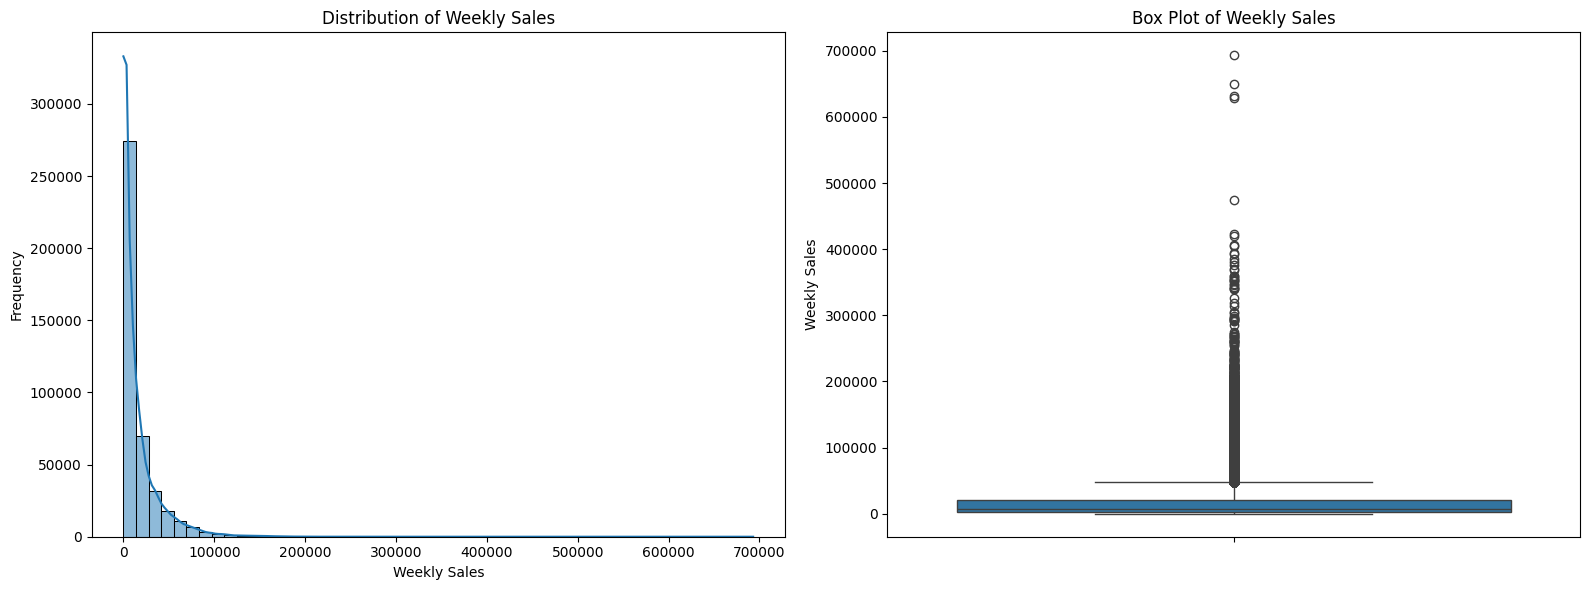

In [31]:
# Chart - 1: Distribution of Weekly Sales
plt.figure(figsize=(16, 6))

# Histogram for Weekly_Sales
plt.subplot(1, 2, 1)
sns.histplot(df['Weekly_Sales'], bins=50, kde=True)
plt.title('Distribution of Weekly Sales')
plt.xlabel('Weekly Sales')
plt.ylabel('Frequency')

# Box plot for Weekly_Sales
plt.subplot(1, 2, 2)
sns.boxplot(y=df['Weekly_Sales'])
plt.title('Box Plot of Weekly Sales')
plt.ylabel('Weekly Sales')

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

I chose a histogram and a box plot to visualize the `Weekly_Sales` distribution for several reasons:

*   **Histogram:** A histogram is excellent for showing the shape of the distribution, its central tendency, spread, and identifying modes. It helps to understand the frequency of different sales ranges.
*   **Box Plot:** A box plot is particularly useful for quickly identifying outliers, skewness, and the spread of the data through its quartiles. It provides a clear visual summary of the five-number summary (minimum, first quartile, median, third quartile, and maximum), especially valuable for detecting extreme values that might be anomalies.

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

From the distribution plots of `Weekly_Sales`, we can observe the following insights:

*   **Right-Skewed Distribution:** The histogram shows that the `Weekly_Sales` data is heavily right-skewed. A large number of weekly sales are concentrated at lower values, while fewer instances have very high sales.
*   **Presence of Outliers:** The box plot clearly indicates the presence of numerous outliers on the higher end of weekly sales. These are sales figures that are significantly higher than the typical sales range.
*   **Negative Sales:** Interestingly, the histogram also reveals a small number of instances with negative weekly sales. These could represent returns or data entry errors and warrant further investigation as anomalies.
*   **Central Tendency and Spread:** The majority of weekly sales fall within a relatively narrow range, but the long tail and outliers suggest that maximum sales can be substantially higher.

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, the gained insights can definitely help create a positive business impact, and they also highlight areas that could lead to negative growth if not addressed:

**Positive Business Impact:**
*   **Anomaly Detection & Data Cleaning:** Identifying outliers (both very high and negative sales) is crucial for data cleaning. Investigating these outliers (e.g., extremely high sales could be promotional events, negative sales could be returns/errors) ensures that forecasting models are trained on clean, representative data. This directly addresses the "Data Cleaning and Anomaly Detection" objective and improves forecast accuracy.
*   **Targeted Strategies:** Understanding the skewed distribution means that most stores/departments have lower weekly sales. This knowledge can help in developing more tailored marketing and inventory strategies for different sales tiers, rather than a one-size-fits-all approach.
*   **Identifying High-Performing Events:** The high-value outliers might correspond to successful promotional campaigns or holiday periods. Analyzing these specific events can help the retailer replicate successful strategies in the future.

**Potential for Negative Growth/Insights Leading to Negative Growth:**
*   **Negative Sales:** The presence of negative `Weekly_Sales` values is a direct indicator of potential problems. If these are due to excessive returns or errors, it means actual revenue is being lost or data integrity is compromised. Without correcting these, financial reporting and business decisions would be flawed, leading to inaccurate performance assessment and potentially negative growth. These need to be properly managed (e.g., by separating returns from sales or correcting data entry) to avoid distorting sales metrics.
*   **Misinterpretation of Average Sales:** Due to the right-skewed distribution, the mean weekly sales might be significantly higher than the median. Relying solely on the mean could lead to overestimating typical store performance and setting unrealistic targets for average-performing stores, potentially causing inefficiencies in inventory and staffing.

Answer Here

#### Chart - 2

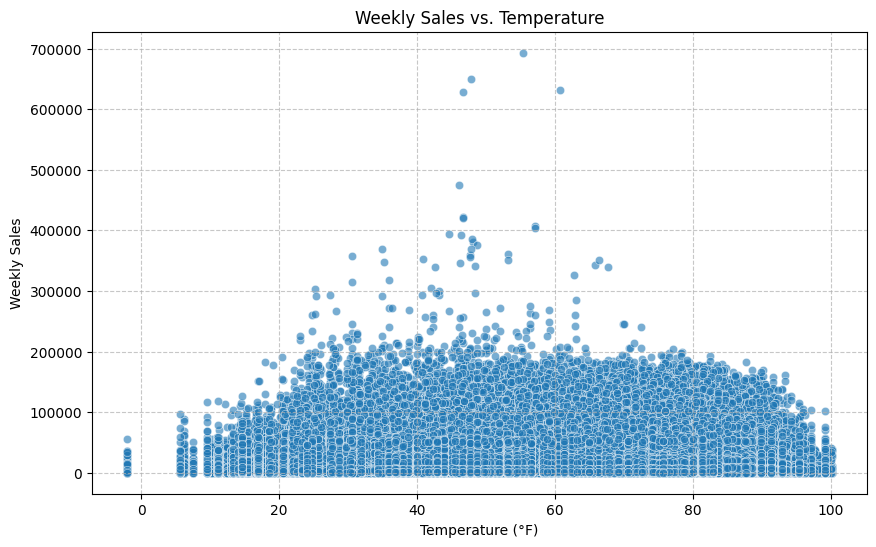

In [32]:
# Chart - 2: Weekly Sales vs. Temperature
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Temperature', y='Weekly_Sales', data=df, alpha=0.6)
plt.title('Weekly Sales vs. Temperature')
plt.xlabel('Temperature (°F)')
plt.ylabel('Weekly Sales')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

##### 1. Why did you pick the specific chart?

I chose a **scatter plot** for visualizing `Weekly_Sales` against `Temperature` because it is the most effective chart type for displaying the relationship or correlation between two continuous numerical variables. Each point on the plot represents a single observation (a week's sales at a specific temperature), allowing us to easily observe patterns, trends, or clusters, and to identify if there's a positive, negative, or no correlation.

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

From the scatter plot of `Weekly_Sales` vs. `Temperature`, we can observe the following insights:

*   **No Strong Linear Correlation:** There doesn't appear to be a strong, clear linear correlation (either positive or negative) between temperature and weekly sales across all data points. The points are widely scattered.
*   **Potential for High Sales at Moderate Temperatures:** While sales vary widely, there seems to be a slight tendency for higher weekly sales to occur within a moderate temperature range (e.g., between 40°F and 70°F), though high sales are also observed at other temperatures.
*   **Sales Variability Across Temperatures:** At almost any given temperature, there's a wide range of weekly sales values, indicating that temperature alone is not the sole determinant of sales performance. Other factors likely play a significant role.
*   **Outliers/High Sales:** The plot confirms the presence of very high `Weekly_Sales` outliers, as identified in Chart 1, which occur across various temperatures.

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, these insights can contribute to a positive business impact and also highlight potential areas for negative growth if not considered:

**Positive Business Impact:**
*   **Informed Inventory Management:** Knowing that there isn't a direct strong correlation between temperature and sales, especially at extreme temperatures, suggests that inventory decisions shouldn't be solely based on weather forecasts. Retailers can avoid overstocking or understocking based on temperature alone and instead focus on other impactful factors.
*   **Targeted Marketing/Promotions:** If certain temperature ranges show a tendency for higher sales, marketing efforts could be strategically planned for those periods. Conversely, if sales are generally lower or more unpredictable at very high or very low temperatures, specific promotions or product mixes could be used to stimulate demand.
*   **Focus on Other Factors:** The lack of a strong direct correlation for temperature emphasizes the importance of investigating other variables (like holidays, markdown events, CPI, unemployment) that might have a more significant impact on sales. This aligns with the project's objective of understanding the impact of external factors.

**Potential for Negative Growth/Insights Leading to Negative Growth:**
*   **Over-reliance on Temperature:** If the retailer *assumes* a strong correlation where none exists, they might make poor decisions. For example, if they expect sales to drop significantly with a slight temperature increase and reduce stock, they could lose sales if other factors drive demand.
*   **Missed Opportunities at "Off-Season" Temperatures:** If the business only focuses on moderate temperature sales, they might miss opportunities to innovate or promote products that sell well during extreme weather, leading to stagnation in those periods.
*   **Ignoring Local Nuances:** This aggregated view might mask store-specific or region-specific temperature sensitivities. A 'one-size-fits-all' approach based on this general finding could be detrimental if some stores *are* highly sensitive to temperature changes.

Answer Here

#### Chart - 3

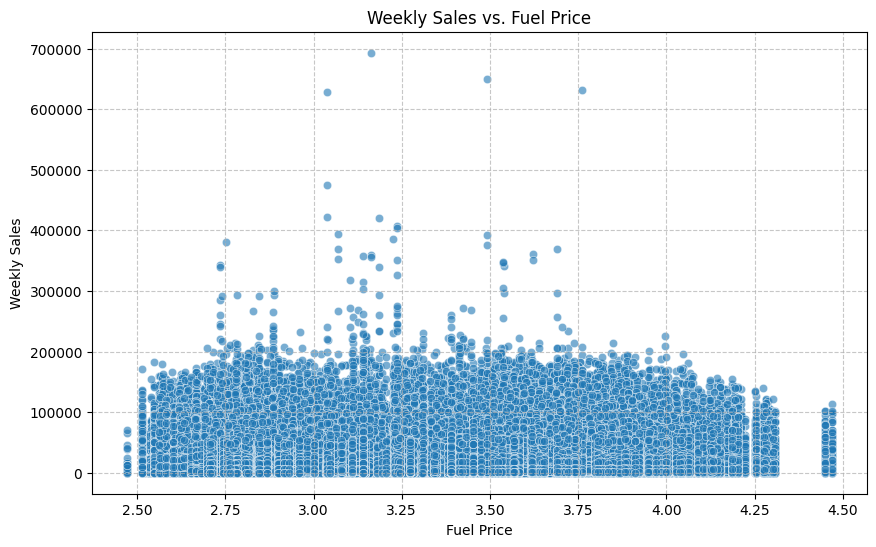

In [33]:
# Chart - 3: Weekly Sales vs. Fuel Price
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Fuel_Price', y='Weekly_Sales', data=df, alpha=0.6)
plt.title('Weekly Sales vs. Fuel Price')
plt.xlabel('Fuel Price')
plt.ylabel('Weekly Sales')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

##### 1. Why did you pick the specific chart?

I chose a **scatter plot** for visualizing `Weekly_Sales` against `Fuel_Price` for the same reasons as Chart 2. It is ideal for showing the relationship between two continuous numerical variables. It allows for easy identification of patterns, trends, or the absence thereof, and helps in understanding if there's any correlation between fuel prices and sales performance.

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

From the scatter plot of `Weekly_Sales` vs. `Fuel_Price`, we can observe the following:

*   **No Strong Linear Correlation:** Similar to temperature, there doesn't appear to be a strong, clear linear correlation between fuel price and weekly sales. The data points are widely scattered across the range of fuel prices.
*   **Sales Variability:** At various fuel price points, there's a wide range of weekly sales, indicating that fuel price is likely not the sole or primary driver of sales. Other factors probably have a more significant influence.
*   **Outliers Present:** The presence of high `Weekly_Sales` outliers is still visible across different fuel price levels, reinforcing the observation from Chart 1 that these extreme sales occur under various conditions.
*   **Concentration of Data:** Most of the sales data is concentrated within a certain range of fuel prices, reflecting the typical market fluctuations, but no distinct pattern emerges regarding sales performance within this range.

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, the insights gained from this chart can contribute to both positive business impacts and highlight areas that could lead to negative growth if not managed correctly:

**Positive Business Impact:**
*   **Refined Forecasting Models:** Understanding that `Fuel_Price` alone doesn't strongly correlate with `Weekly_Sales` means that forecasting models shouldn't overemphasize this variable. This helps in building more accurate demand forecasting models by correctly weighting the influence of various external factors, aligning with the project's objective of developing robust models.
*   **Strategic Planning:** Retailers can be more confident that moderate fluctuations in fuel prices may not drastically impact overall sales, allowing them to focus resources on more influential factors or develop strategies that are less sensitive to fuel cost changes. For example, if transportation costs increase due to fuel, they might need to absorb some costs rather than expecting a direct sales drop.
*   **Cross-Factor Analysis:** This insight prompts further investigation into how `Fuel_Price` might interact with other variables (e.g., during holidays or with specific markdown events) to impact sales, rather than treating it in isolation.

**Potential for Negative Growth/Insights Leading to Negative Growth:**
*   **Ignoring Indirect Impacts:** While a direct correlation isn't apparent, sustained high fuel prices can reduce consumer disposable income, leading to indirect negative impacts on sales. Ignoring these indirect, long-term effects could lead to declining sales as consumer spending habits shift.
*   **Misallocating Marketing Resources:** If a business incorrectly assumes a strong direct link, they might launch ineffective promotions tied to fuel price changes, wasting marketing budget and potentially alienating customers.
*   **Overlooking Regional Differences:** This aggregated view may hide specific regional or demographic sensitivities to fuel prices. For instance, stores in areas with longer commutes or lower-income populations might be more affected by fuel price changes. A 'one-size-fits-all' approach based on this general finding could lead to negative growth in affected regions.

Answer Here

#### Chart - 4

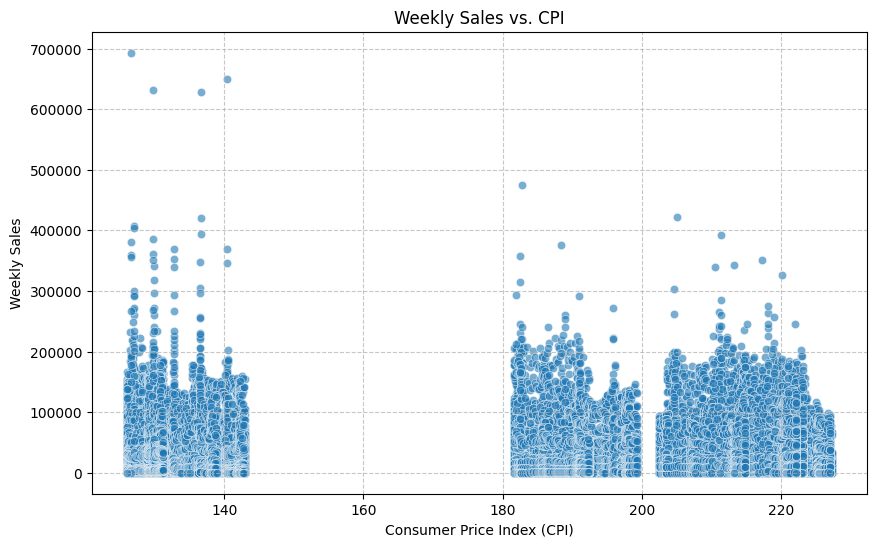

In [34]:
# Chart - 4: Weekly Sales vs. CPI
plt.figure(figsize=(10, 6))
sns.scatterplot(x='CPI', y='Weekly_Sales', data=df, alpha=0.6)
plt.title('Weekly Sales vs. CPI')
plt.xlabel('Consumer Price Index (CPI)')
plt.ylabel('Weekly Sales')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

##### 1. Why did you pick the specific chart?

I chose a **scatter plot** for visualizing `Weekly_Sales` against `CPI` because it is effective for displaying the relationship between two continuous numerical variables. It allows us to observe patterns, trends, or the absence thereof, and to identify if there's a positive, negative, or no correlation between the Consumer Price Index and weekly sales.

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

From the scatter plot of `Weekly_Sales` vs. `CPI`, we can observe the following:

*   **No Strong Linear Correlation:** There does not appear to be a strong, clear linear correlation between the CPI and weekly sales across all data points. The points are widely scattered.
*   **Sales Variability Across CPI Ranges:** For almost any given CPI value, there's a wide range of weekly sales values, indicating that CPI alone is not the sole determinant of sales performance. Other factors likely play a significant role.
*   **Concentration of Data:** Most of the sales data is concentrated within a certain range of CPI values, which is expected as CPI typically changes gradually over time. Within this range, sales fluctuate significantly.
*   **Outliers Persist:** The presence of very high `Weekly_Sales` outliers is still visible across various CPI levels, reinforcing previous observations that these extreme sales occur under diverse economic conditions.

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, the insights gained from this chart can contribute to both positive business impacts and highlight areas that could lead to negative growth if not managed correctly:

**Positive Business Impact:**
*   **Informed Economic Analysis:** Understanding that `CPI` doesn't show a strong *direct* linear correlation with `Weekly_Sales` can help refine economic analysis. It suggests that while general economic conditions (reflected by CPI) are important, their impact on weekly sales might be more complex, potentially indirect, or influenced by other factors like specific promotions or seasonality. This can guide a more nuanced approach to economic forecasting.
*   **Avoid Misguided Strategies:** The lack of a direct strong correlation means that retailers should avoid making sales strategies solely based on CPI trends. This prevents misallocation of resources towards initiatives that assume a direct link where one may not exist.
*   **Focus on Micro-Factors:** This observation reinforces the need to delve deeper into micro-economic factors or store-specific conditions that might be more predictive of sales, aligning with the project's goal of developing robust forecasting models.

**Potential for Negative Growth/Insights Leading to Negative Growth:**
*   **Ignoring Indirect or Lagging Effects:** While a direct instantaneous correlation isn't evident, CPI can indicate inflationary pressures that, over time, erode consumer purchasing power. Ignoring these lagging or indirect effects could lead to a gradual decline in sales as customers become more price-sensitive or cut back on discretionary spending.
*   **Missed Opportunities for Proactive Pricing:** If CPI is rising (inflation), but sales don't immediately drop, a business might miss opportunities to adjust pricing strategies proactively to maintain profit margins without significantly impacting demand.
*   **Simplistic Economic Models:** Overly simplistic sales forecasting models that include CPI as a primary direct driver might be inaccurate, leading to poor inventory management or marketing decisions that negatively affect growth.

Answer Here

#### Chart - 5

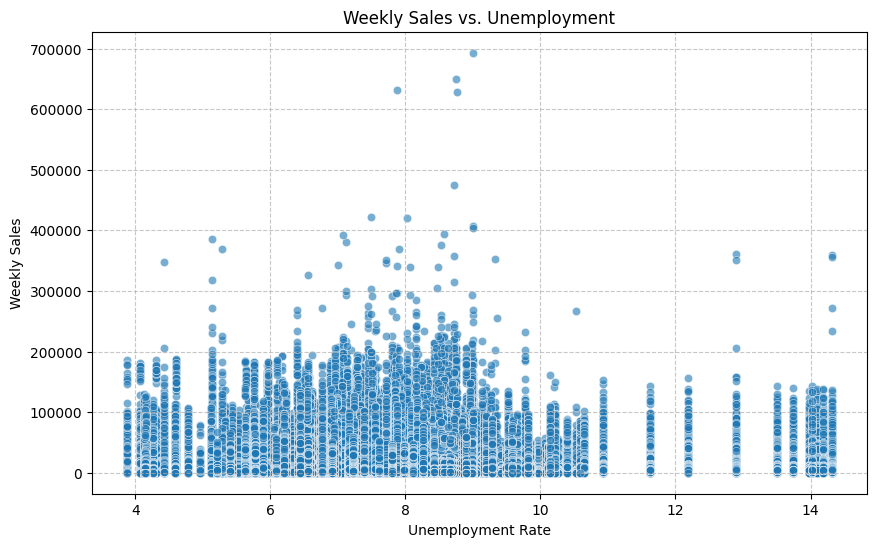

In [35]:
# Chart - 5: Weekly Sales vs. Unemployment
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Unemployment', y='Weekly_Sales', data=df, alpha=0.6)
plt.title('Weekly Sales vs. Unemployment')
plt.xlabel('Unemployment Rate')
plt.ylabel('Weekly Sales')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

##### 1. Why did you pick the specific chart?

A **scatter plot** is chosen to visualize `Weekly_Sales` against `Unemployment` because it's the most suitable chart for examining the relationship between two continuous numerical variables. It effectively shows the distribution of data points, helping to identify any linear or non-linear correlations, clusters, or outliers between the unemployment rate and sales performance.

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

From the scatter plot of `Weekly_Sales` vs. `Unemployment`, we can observe the following:

*   **Weak Negative Correlation Trend:** There appears to be a very weak, slightly negative correlation trend. As the unemployment rate tends to increase, the maximum and average weekly sales values *might* slightly decrease, but this is not a strong or consistent pattern.
*   **High Sales Variability:** Similar to other economic indicators, there is significant variability in `Weekly_Sales` at almost every level of unemployment. This suggests that unemployment is not the sole predictor of sales and other factors are strongly influencing sales figures.
*   **Outliers Across the Board:** High `Weekly_Sales` outliers are present across various unemployment rates, indicating that exceptional sales weeks can occur regardless of the prevailing unemployment figures within the observed range.
*   **Concentration in Lower Unemployment:** Most data points are concentrated in lower unemployment rate ranges (e.g., below 8%), reflecting the general economic conditions during the dataset's period. Within this common range, sales vary widely.

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, the insights gained from this chart can offer both positive business impacts and reveal potential areas for negative growth if not carefully considered:

**Positive Business Impact:**
*   **Refined Economic Modeling:** The weak correlation suggests that `Unemployment` might not be as direct a driver of `Weekly_Sales` as initially hypothesized. This is valuable for building more accurate demand forecasting models by preventing an overemphasis on this single variable. Instead, the model can focus on variables with stronger, more direct impacts.
*   **Strategic Resilience Planning:** If a slight increase in unemployment doesn't dramatically impact sales, it suggests the business might be somewhat resilient to minor economic downturns, allowing for more stable long-term planning and less panic-driven reactions to economic news.
*   **Focus on Localized Impact:** While the overall correlation is weak, it's possible that unemployment affects specific store types, departments, or regions differently. This insight prompts deeper investigation into segmented data to uncover localized impacts, leading to more personalized marketing and inventory strategies.

**Potential for Negative Growth/Insights Leading to Negative Growth:**
*   **Ignoring Cumulative Economic Strain:** Even a weak negative correlation, if sustained, can indicate a slow erosion of consumer confidence and disposable income. Ignoring this cumulative economic strain, especially during prolonged periods of higher unemployment, could lead to a gradual, unchecked decline in sales.
*   **Missed Opportunity for Counter-Cyclical Marketing:** If the business misinterprets the weak correlation as 'no impact,' it might miss opportunities to implement counter-cyclical marketing strategies (e.g., value-focused promotions during times of rising unemployment) that could maintain or even boost sales.
*   **Assumptions of Uniformity:** The overall weak correlation might mask significant negative impacts on specific consumer segments or product categories that are more sensitive to unemployment rates. A 'one-size-fits-all' approach could be detrimental to these vulnerable segments.

Answer Here

#### Chart - 6

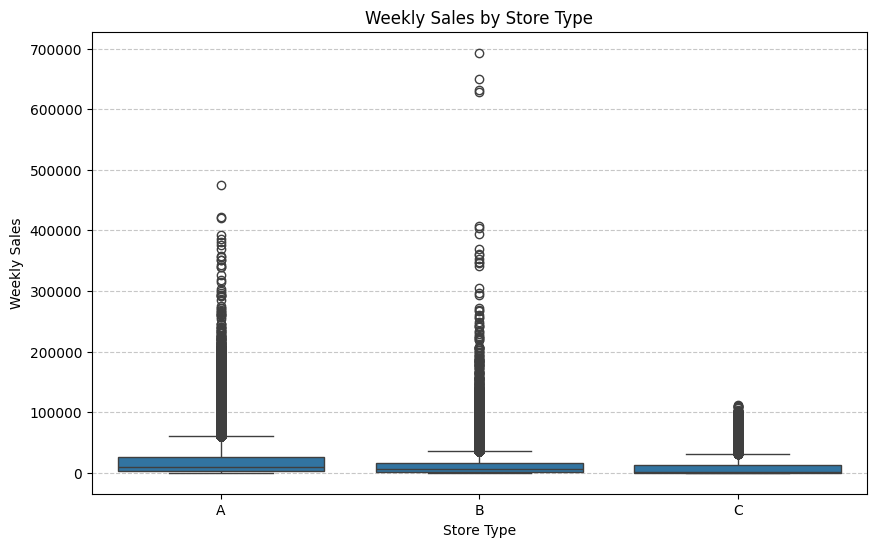

In [36]:
# Chart - 6: Weekly Sales by Store Type
plt.figure(figsize=(10, 6))
sns.boxplot(x='Type', y='Weekly_Sales', data=df, order=['A', 'B', 'C'])
plt.title('Weekly Sales by Store Type')
plt.xlabel('Store Type')
plt.ylabel('Weekly Sales')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

##### 1. Why did you pick the specific chart?

I chose a **box plot** to visualize `Weekly_Sales` by `Store Type` because it is ideal for comparing the distribution of a continuous variable across different categorical groups. A box plot efficiently displays the median, quartiles, and potential outliers for each store type, allowing for a clear comparison of their sales performance and variability. An ordered display (A, B, C) provides a structured view.

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

From the box plot of `Weekly_Sales` by `Store Type`, we can observe the following insights:

*   **Store Type A has the Highest Sales:** Store Type A consistently shows the highest median weekly sales and also has the largest spread of sales values, indicating it generally generates more revenue than other types.
*   **Store Type B is Mid-Range:** Store Type B has a lower median weekly sales compared to Type A but is significantly higher than Type C. It also exhibits a considerable range of sales, although less than Type A.
*   **Store Type C has the Lowest Sales:** Store Type C has the lowest median weekly sales and the narrowest interquartile range, suggesting it generates the least revenue and has less sales variability compared to Types A and B.
*   **Outliers in All Types:** All three store types exhibit numerous outliers on the higher end of `Weekly_Sales`, indicating that even lower-performing store types can have exceptional sales weeks.
*   **Negative Sales Present:** The box plots also confirm the presence of negative `Weekly_Sales` (though few in number) across all store types, which warrants further investigation.

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, these insights are highly valuable for creating a positive business impact and can also highlight areas that could lead to negative growth if overlooked:

**Positive Business Impact:**
*   **Targeted Resource Allocation:** Knowing the distinct performance differences between store types (A > B > C) enables targeted resource allocation. Higher-performing Type A stores might receive more investment for growth, while Type C stores could be analyzed for optimization or specific interventions. This aligns directly with the project's objective of 'Segment stores based on performance' and 'tailored inventory management plans'.
*   **Personalized Marketing Strategies:** Different store types likely cater to different customer demographics or have varied market baskets. This segmentation allows for the creation of *personalized marketing strategies* tailored to each store type's sales patterns and potential, enhancing effectiveness and ROI.
*   **Inventory Optimization:** Inventory strategies can be refined for each store type. Type A stores might require larger, more diverse inventories, while Type C stores could focus on high-turnover items. This directly supports the project's aim to optimize store performance and inventory management.
*   **Performance Benchmarking:** The clear sales hierarchy provides a benchmark. Type B and C stores can learn best practices from Type A, or their unique challenges can be investigated to improve their performance.

**Potential for Negative Growth/Insights Leading to Negative Growth:**
*   **One-Size-Fits-All Approach:** If the retailer ignores these distinct differences and applies a 'one-size-fits-all' strategy, it could lead to:
    *   **Underperformance in Type A:** Missing growth opportunities by not adequately stocking or promoting for their higher demand.
    *   **Overstocking/Losses in Type C:** Wasting resources and incurring losses due to excessive inventory in lower-demand stores.
*   **Misguided Performance Expectations:** Setting the same sales targets for all store types would be unrealistic and could demotivate staff in Type C stores or under-challenge Type A stores.
*   **Ignoring Underlying Issues in Lower-Performing Stores:** While Type C stores have lower sales, simply accepting this without investigating the root causes (e.g., poor location, local competition, inadequate product mix) could lead to their continued decline or even closure, representing negative growth.

Answer Here

#### Chart - 7

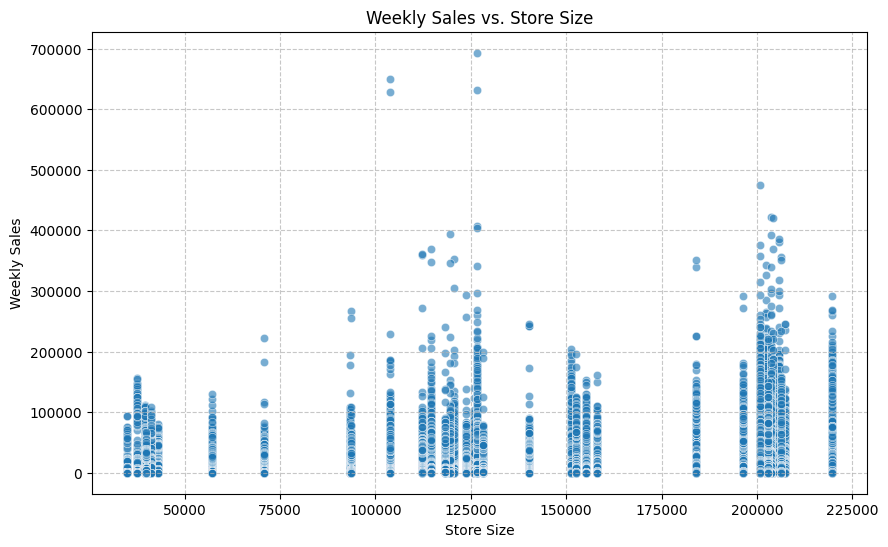

In [37]:
# Chart - 7: Weekly Sales vs. Store Size
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Size', y='Weekly_Sales', data=df, alpha=0.6)
plt.title('Weekly Sales vs. Store Size')
plt.xlabel('Store Size')
plt.ylabel('Weekly Sales')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

##### 1. Why did you pick the specific chart?

I chose a **scatter plot** for visualizing `Weekly_Sales` against `Size` because it is effective for displaying the relationship between two continuous numerical variables. It allows for the observation of patterns, trends, or the absence thereof, and helps to identify if there's a positive, negative, or no correlation between the size of a store and its weekly sales.

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

From the scatter plot of `Weekly_Sales` vs. `Store Size`, we can observe the following insights:

*   **Positive Correlation:** There appears to be a general positive correlation between `Store Size` and `Weekly_Sales`. Larger stores tend to have higher weekly sales, although there is considerable variability.
*   **Sales Clusters by Size:** The data points seem to cluster around certain store sizes, possibly corresponding to different store formats or types (e.g., small, medium, large). Within these clusters, there's still a range of sales.
*   **Outliers at Higher Sales:** Even for smaller store sizes, there are instances of very high `Weekly_Sales` (outliers), indicating that some smaller stores can be exceptionally successful, perhaps due to location, specialization, or effective management.
*   **Minimum Sales Across Sizes:** Even very large stores can have relatively low weekly sales, suggesting that size alone does not guarantee high sales, and other factors are at play.

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, the insights gained from this chart can significantly contribute to positive business impact and also highlight potential areas for negative growth:

**Positive Business Impact:**
*   **Strategic Planning & Expansion:** The positive correlation between size and sales can inform strategies for store expansion or the development of new store formats. Retailers might prioritize investing in larger stores or expanding existing ones to maximize revenue potential, aligning with the project's objective of optimizing store performance.
*   **Inventory Management by Size:** Knowing that larger stores generally have higher sales suggests they can handle (and require) a wider variety and larger volume of inventory. This can lead to more efficient inventory allocation across the different store sizes, reducing overstocking in smaller stores and understocking in larger ones.
*   **Benchmarking and Performance Analysis:** Outperforming smaller stores (high sales for their size) can be studied to identify best practices that could be replicated. Conversely, underperforming larger stores might signal inefficiencies or issues that need immediate attention.

**Potential for Negative Growth/Insights Leading to Negative Growth:**
*   **Over-reliance on Size:** Blindly assuming that 'bigger is always better' without considering other factors (like location, local demographics, or competition) could lead to investing in large stores that don't perform well, resulting in significant financial losses.
*   **Ignoring Niche Markets:** If smaller stores are dismissed as less profitable, the business might miss opportunities in niche markets where smaller, specialized stores could thrive and offer better ROI than a large, general store.
*   **Inefficient Resource Allocation:** Without understanding the nuances, allocating resources solely based on store size without considering individual store performance (e.g., providing the same staffing ratios to all large stores, even underperforming ones) could lead to inefficient operations and reduced profitability.

Answer Here

#### Chart - 8

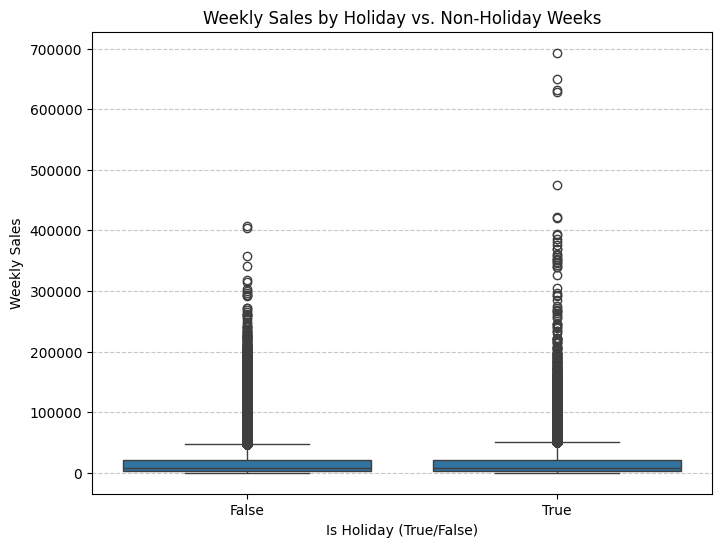

In [38]:
# Chart - 8: Weekly Sales by Holiday vs. Non-Holiday Weeks
plt.figure(figsize=(8, 6))
sns.boxplot(x='IsHoliday', y='Weekly_Sales', data=df)
plt.title('Weekly Sales by Holiday vs. Non-Holiday Weeks')
plt.xlabel('Is Holiday (True/False)')
plt.ylabel('Weekly Sales')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

##### 1. Why did you pick the specific chart?

I chose a **box plot** to visualize `Weekly_Sales` by `IsHoliday` because it is effective for comparing the distribution of a continuous variable (`Weekly_Sales`) across two categorical groups (`True` for holiday weeks and `False` for non-holiday weeks). This allows for a clear comparison of sales performance, variability, and potential outliers during holiday versus non-holiday periods.

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

From the box plot of `Weekly_Sales` by `IsHoliday`, we can observe the following insights:

*   **Higher Sales During Holiday Weeks:** As expected, holiday weeks generally show significantly higher median `Weekly_Sales` compared to non-holiday weeks. The entire distribution of sales appears to shift upwards during holiday periods.
*   **Increased Variability in Holiday Sales:** Holiday weeks also exhibit a larger interquartile range (IQR) and a wider spread of sales, indicating greater variability in sales performance. This suggests that while holidays generally boost sales, the magnitude of that boost can vary considerably.
*   **More Extreme Outliers in Holiday Weeks:** There are numerous, and often more extreme, high `Weekly_Sales` outliers during holiday weeks, reinforcing the idea that certain holiday periods can lead to exceptionally high sales volumes.
*   **Baseline Sales:** Non-holiday weeks establish a baseline sales performance with a tighter distribution and lower median, but still show some outliers, suggesting that strong sales can occur outside of major holidays due to other factors (e.g., promotions).

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, these insights are crucial for creating a positive business impact and can also highlight areas that could lead to negative growth if not addressed:

**Positive Business Impact:**
*   **Optimized Inventory and Staffing:** Understanding the significant sales surge during holiday weeks allows for proactive inventory planning and increased staffing. This prevents stockouts during peak demand and ensures adequate customer service, directly impacting customer satisfaction and maximizing holiday revenues.
*   **Strategic Marketing and Promotions:** Retailers can tailor marketing campaigns and promotions specifically for holiday periods to capitalize on increased consumer spending. Identifying which holidays drive the most significant sales allows for focused efforts.
*   **Enhanced Demand Forecasting:** Incorporating `IsHoliday` as a key feature in demand forecasting models (as highlighted in the project summary) will significantly improve the accuracy of sales predictions, leading to better operational efficiency and reduced waste.

**Potential for Negative Growth/Insights Leading to Negative Growth:**
*   **Underestimating Holiday Demand:** If the retailer *underestimates* the sales potential of holiday weeks, they could face severe stockouts, leading to lost sales, frustrated customers, and a negative brand perception.
*   **Overspending on Non-Impactful Holidays:** Not all holidays have the same impact on sales. If the business applies a 'blanket' holiday strategy without differentiating, it could lead to inefficient spending on marketing or promotions for less impactful holidays, wasting resources.
*   **Ignoring Non-Holiday Growth Opportunities:** While holidays are important, neglecting to analyze and stimulate sales during non-holiday periods could lead to flat or declining sales for a significant portion of the year, hindering overall growth. The outliers in non-holiday weeks show that growth is possible, but needs to be driven by other strategies.

Answer Here

#### Chart - 9

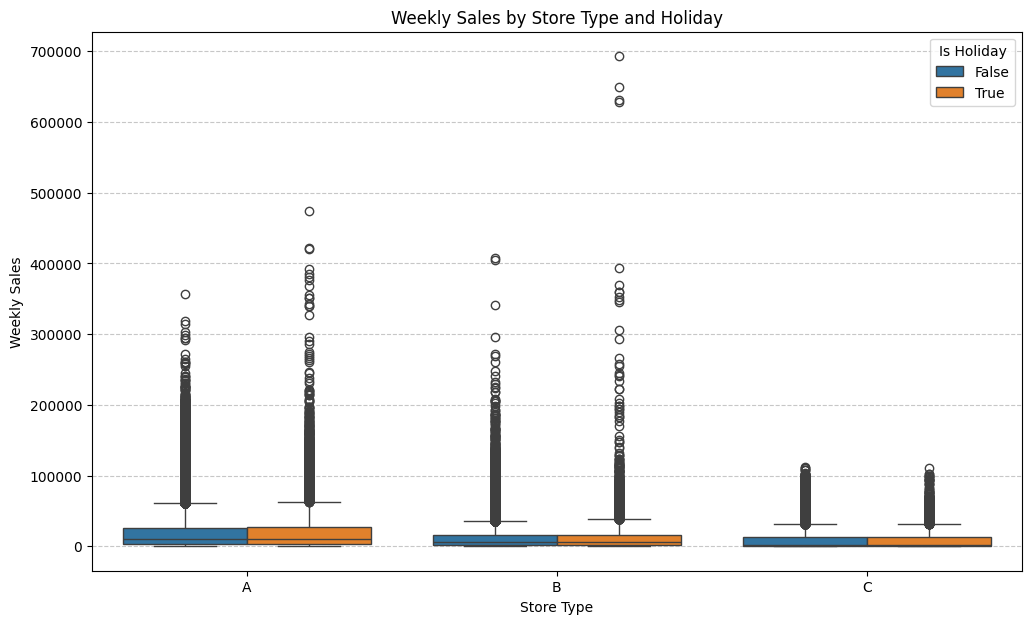

In [39]:
# Chart - 9: Weekly Sales by Store Type and Holiday
plt.figure(figsize=(12, 7))
sns.boxplot(x='Type', y='Weekly_Sales', hue='IsHoliday', data=df, order=['A', 'B', 'C'])
plt.title('Weekly Sales by Store Type and Holiday')
plt.xlabel('Store Type')
plt.ylabel('Weekly Sales')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Is Holiday')
plt.show()

##### 1. Why did you pick the specific chart?

I chose a **grouped box plot** (using `hue='IsHoliday'`) to visualize `Weekly_Sales` by `Store Type` and `IsHoliday`. This chart is excellent for comparing the distribution of a continuous variable (`Weekly_Sales`) across multiple categorical groups simultaneously. It allows us to not only see the sales performance of each store type but also how holiday periods impact each type differently, revealing potential interactions between these two factors.

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

From the grouped box plot of `Weekly_Sales` by `Store Type` and `IsHoliday`, we can observe the following insights:

*   **Holiday Impact Across All Types:** All store types (A, B, C) experience a significant increase in `Weekly_Sales` during holiday weeks compared to non-holiday weeks. This confirms the general trend observed in Chart 8.
*   **Type A's Dominance Reinforced:** Type A stores maintain their lead in sales during both holiday and non-holiday periods, consistently showing the highest median and upper quartile sales. The absolute increase in sales during holidays is also largest for Type A stores.
*   **Type C's Limited Response:** Type C stores, while still seeing a holiday boost, show the smallest absolute increase in `Weekly_Sales` during holidays. Their sales remain considerably lower and less variable compared to Type A and B.
*   **Variability:** The spread of sales (IQR and outliers) is generally larger during holiday weeks for all store types, with Type A showing the most extreme high outliers during holidays. This indicates that while holidays are good for sales, the degree of success varies more during these periods.

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, these detailed insights are highly beneficial for creating a positive business impact and pinpointing areas for potential negative growth:

**Positive Business Impact:**
*   **Refined Segmentation Strategies:** This chart refines the store segmentation (from Chart 6) by adding the holiday dimension. It allows for *even more personalized marketing and inventory strategies* for each store type *during specific periods*. For example, Type A stores can be heavily stocked and aggressively promoted during holidays, while Type C stores might require a more conservative holiday strategy.
*   **Optimized Holiday Planning:** The differing holiday responses across store types enable a more nuanced approach to holiday planning. Resources (staff, marketing budget, specific products) can be strategically allocated based on each type's typical holiday sales uplift, maximizing ROI and operational efficiency.
*   **Identifying Underperforming Holiday Performers:** If a Type A store doesn't show the expected holiday sales surge, it flags a specific problem that needs immediate investigation (e.g., local competition, poor holiday-specific product selection, ineffective promotions).

**Potential for Negative Growth/Insights Leading to Negative Growth:**
*   **Ignoring Type C's Holiday Potential:** While Type C stores have lower absolute holiday sales, dismissing their potential entirely could lead to missed opportunities. A small, targeted holiday promotion might still yield a positive return. Overlooking them could mean leaving money on the table.
*   **Misallocating Resources:** Assuming all holiday efforts should be equal across all stores, or even across all Type A stores, could lead to overspending in some areas and under-capitalizing in others. For instance, if a Type A store historically has a lower holiday uplift, an overly aggressive stocking strategy could lead to excess inventory.
*   **Failure to Adapt to Variability:** The increased variability during holidays (especially for Type A) means that a 'standard' holiday plan might not always hit the mark. Failure to monitor real-time sales and adapt inventory or promotional strategies could lead to either stockouts or overstocking, both negatively impacting profitability.

Answer Here

#### Chart - 10

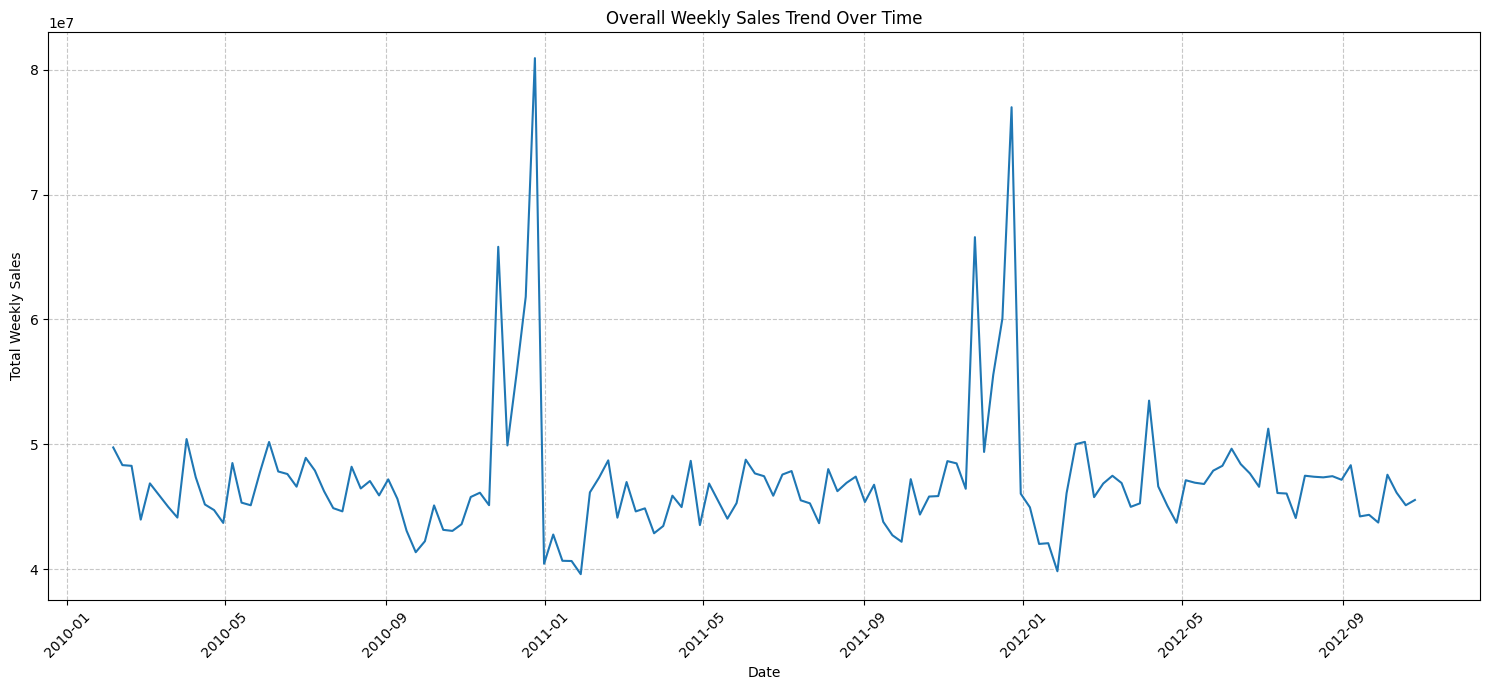

In [40]:
# Chart - 10: Weekly Sales Trend Over Time (Overall)
# Convert 'Date' column to datetime objects
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')

# Group by Date and sum Weekly_Sales to get overall weekly sales
overall_weekly_sales = df.groupby('Date')['Weekly_Sales'].sum().reset_index()

# Sort by Date to ensure proper time series plotting
overall_weekly_sales = overall_weekly_sales.sort_values('Date')

plt.figure(figsize=(15, 7))
sns.lineplot(x='Date', y='Weekly_Sales', data=overall_weekly_sales)
plt.title('Overall Weekly Sales Trend Over Time')
plt.xlabel('Date')
plt.ylabel('Total Weekly Sales')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

I chose a **line plot** to visualize the `Overall Weekly Sales Trend Over Time`. A line plot is the most appropriate chart type for displaying time-series data, as it clearly shows the progression of a variable over continuous time. It helps in identifying trends, seasonality, cycles, and irregular fluctuations in total weekly sales.

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

From the line plot of `Overall Weekly Sales Trend Over Time`, we can observe the following insights:

*   **Clear Seasonality:** There is a distinct seasonal pattern in weekly sales. Peaks typically occur around major holidays (e.g., end-of-year holidays like Christmas/New Year, or other major events), and sales dip during off-peak seasons.
*   **Overall Sales Fluctuation:** The overall sales show a fluctuating pattern, reinforcing the idea that sales are not static and are influenced by various factors that change over time.
*   **Potential Growth/Decline Over Years:** By observing the peaks and troughs across the entire time period, one can infer if there's an overall growth or decline trend in total sales, or if sales are stable over the observed years. (More detailed analysis would be needed for a definitive conclusion on long-term trends).
*   **Impact of Specific Events:** The sharp spikes clearly correspond to the holiday weeks identified previously, demonstrating the strong influence of these events on overall sales volume.

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, these insights are fundamental for creating a positive business impact and identifying potential areas for negative growth:

**Positive Business Impact:**
*   **Predictive Demand Forecasting:** Understanding the seasonal and cyclical patterns is crucial for `Demand Forecasting and Time-Series Analysis` (a key project objective). This allows the retailer to accurately predict future sales, optimize inventory levels, manage supply chains effectively, and plan staffing needs well in advance.
*   **Strategic Planning for Peak Seasons:** With clear knowledge of peak sales periods, the business can launch targeted marketing campaigns, special promotions, and product assortments to maximize revenue during these high-demand times.
*   **Resource Optimization:** Identifying periods of lower sales allows for strategic planning of maintenance, staff training, or less aggressive marketing, optimizing resource allocation throughout the year.

**Potential for Negative Growth/Insights Leading to Negative Growth:**
*   **Ignoring Seasonal Downturns:** If the business fails to anticipate and plan for seasonal dips in sales, it could lead to overstaffing, excessive inventory, and higher operating costs during these periods, eroding profitability.
*   **Missed Opportunities During Peaks:** Failure to adequately prepare for peak seasons (e.g., insufficient inventory, inadequate staffing, lack of promotions) directly translates to lost sales and customer dissatisfaction, leading to negative growth.
*   **Stagnant or Declining Trends:** If the overall trend shows stagnation or decline over the years, it indicates fundamental issues (e.g., increasing competition, changing consumer preferences, economic shifts) that need strategic intervention to avoid long-term negative growth. This chart helps in early detection.

Answer Here

#### Chart - 11

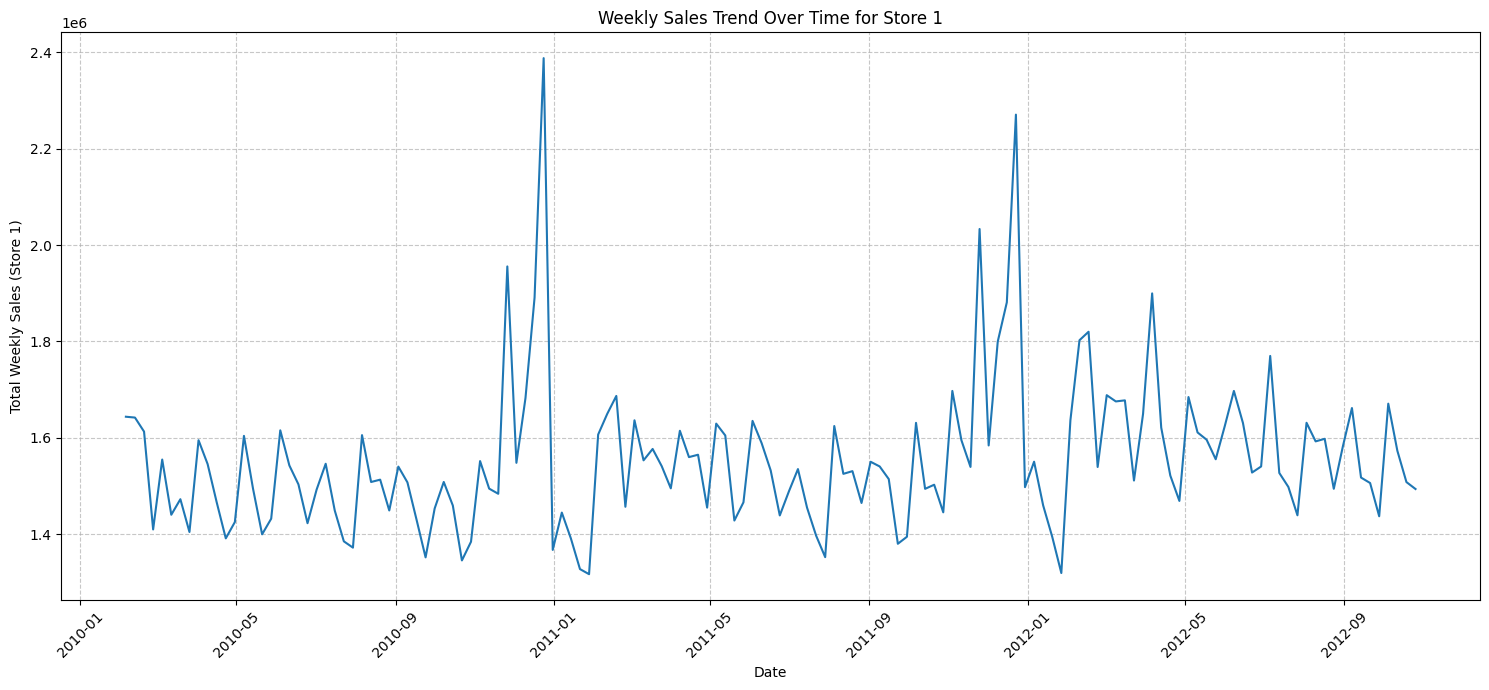

In [41]:
# Chart - 11: Weekly Sales Trend for a Specific Store (Example: Store 1)

# Filter data for a specific store (e.g., Store 1)
store_1_sales = df[df['Store'] == 1].groupby('Date')['Weekly_Sales'].sum().reset_index()
store_1_sales = store_1_sales.sort_values('Date')

plt.figure(figsize=(15, 7))
sns.lineplot(x='Date', y='Weekly_Sales', data=store_1_sales)
plt.title('Weekly Sales Trend Over Time for Store 1')
plt.xlabel('Date')
plt.ylabel('Total Weekly Sales (Store 1)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

I chose a **line plot** to visualize the `Weekly Sales Trend Over Time for a Specific Store` (Store 1 in this example). This chart is optimal for observing the time-series behavior of sales for an individual entity. It allows for the identification of store-specific trends, seasonality, and the impact of local events that might be obscured in an aggregated view. This helps in understanding individual store dynamics.

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

From the line plot of `Weekly Sales Trend Over Time for Store 1`, we can observe the following insights:

*   **Store-Specific Seasonality:** Store 1 also exhibits clear seasonal sales patterns, which align with the overall trends but might have unique characteristics in terms of magnitude or timing of peaks/troughs.
*   **Local Event Impact:** This granular view can potentially highlight the impact of store-specific promotions, local events, or regional economic shifts that might not be visible at an aggregated level. For example, a sudden drop or spike not seen in overall sales could be due to a local factor.
*   **Consistency vs. Volatility:** The plot shows the consistency or volatility of sales for Store 1 over time. Some stores might have more stable sales, while others are more prone to large fluctuations.
*   **Negative Sales Instances:** Specific dips below zero for Store 1 highlight weeks with negative net sales, which is an anomaly that warrants investigation at the individual store level.

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, these store-specific insights are crucial for localized decision-making and preventing negative growth:

**Positive Business Impact:**
*   **Hyper-Local Inventory and Marketing:** Understanding individual store sales trends enables highly targeted inventory management and marketing strategies for each store. This ensures that Store 1 (or any specific store) is stocked with relevant products and promoted effectively based on its unique customer base and local demand patterns, directly fulfilling the project's goal of 'personalized marketing and inventory strategies'.
*   **Performance Monitoring and Intervention:** This chart is vital for monitoring the health of individual stores. A sudden, unexpected decline in sales for Store 1 could trigger an immediate investigation into local issues (e.g., new competitor, operational problems, management changes), allowing for timely intervention before problems escalate.
*   **Benchmarking Across Stores:** Comparing the sales trends of different stores can identify best performers whose strategies can be emulated, and underperformers that need support or a revised approach.

**Potential for Negative Growth/Insights Leading to Negative Growth:**
*   **Ignoring Local Issues:** If individual store performance is not closely monitored (relying only on overall trends), local problems that contribute to negative growth (like persistent low sales or recurring negative sales weeks) could go unnoticed until they severely impact overall profitability.
*   **One-Size-Fits-All Approach:** Applying broad, company-wide strategies without considering unique store trends can be detrimental. For example, a promotion successful nationwide might fail in Store 1 due to local factors, leading to wasted marketing spend and potential negative sales.
*   **Delayed Problem Resolution:** A lack of granular trend analysis for individual stores could delay the identification and resolution of issues that are causing localized negative growth, allowing them to fester and cause greater damage.

Answer Here

#### Chart - 12

C:\Users\shela\AppData\Local\Temp\ipykernel_17252\4068648990.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Dept', y='Weekly_Sales', data=top_10_depts, palette='viridis')


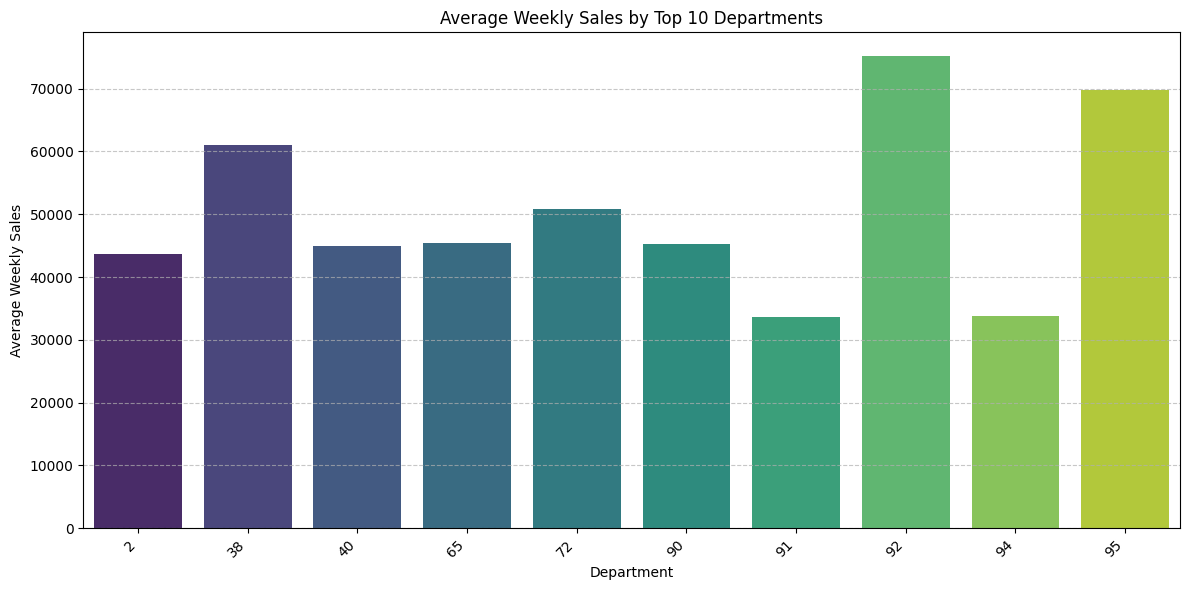

In [42]:
# Chart - 12: Average Weekly Sales by Department (Top 10 Departments)

# Calculate average weekly sales per department
avg_sales_by_dept = df.groupby('Dept')['Weekly_Sales'].mean().sort_values(ascending=False).reset_index()

# Get the top 10 departments by average weekly sales
top_10_depts = avg_sales_by_dept.head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x='Dept', y='Weekly_Sales', data=top_10_depts, palette='viridis')
plt.title('Average Weekly Sales by Top 10 Departments')
plt.xlabel('Department')
plt.ylabel('Average Weekly Sales')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

I chose a **bar plot** to visualize the `Average Weekly Sales by Top 10 Departments`. A bar plot is ideal for comparing discrete categories (departments) based on a single numerical measure (average weekly sales). It effectively highlights which departments are the highest performers and allows for quick visual comparison between them.

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

From the bar plot of `Average Weekly Sales by Top 10 Departments`, we can observe the following insights:

*   **Varying Departmental Performance:** There's a clear hierarchy in average weekly sales among departments. Some departments significantly outperform others, indicating varying demand or profitability.
*   **Identification of Key Departments:** The chart clearly identifies the top-performing departments, which are critical revenue drivers for the business. These departments warrant special attention.
*   **Potential for Specific Strategies:** The distinct sales figures for each department suggest that a 'one-size-fits-all' strategy for inventory or promotion across all departments would be inefficient. Instead, department-specific strategies are needed.
*   **Outliers in Departmental Sales:** While this plot shows averages, it implicitly points to the fact that within these departments, there could be very high individual weekly sales (outliers) that contribute to their high averages.

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, these departmental insights are extremely valuable for creating positive business impact and avoiding negative growth:

**Positive Business Impact:**
*   **Targeted Inventory and Merchandising:** Identifying top-performing departments allows for optimized inventory levels and merchandising strategies. High-volume departments can receive more floor space, marketing focus, and deeper stock, ensuring customer demand is met and sales are maximized.
*   **Resource Allocation:** Management can allocate resources (staff, marketing budget, capital investment) strategically to departments with the highest average sales, or to those with significant growth potential, thereby maximizing overall profitability.
*   **Market Basket Analysis (Inference):** Although individual transaction data is limited, understanding high-performing departments can guide `Market Basket Inference` (a project objective). If certain departments consistently sell well, retailers can infer popular product groupings and cross-selling opportunities.
*   **Underperforming Department Intervention:** This chart can also highlight departments that are significantly underperforming (if we were to view all departments), prompting investigations into why and what interventions (e.g., product mix change, pricing adjustment, promotion) might improve their sales.

**Potential for Negative Growth/Insights Leading to Negative Growth:**
*   **Ignoring Low-Performing Departments:** While focusing on top performers is good, completely neglecting lower-performing departments could lead to their continued decline, or even to missing a department with high potential that just needs the right strategy.
*   **Overstocking High-Volume Departments:** Without careful forecasting, merely stocking 'more' in high-average sales departments could lead to overstocking if sales are volatile or if the average masks periods of low demand.
*   **Failure to Diversify:** Over-reliance on a few top-performing departments could be risky. If market trends shift or a competitor emerges for these key departments, the entire business could suffer. This chart emphasizes the need to understand if the business is too concentrated.

Answer Here

#### Chart - 13

C:\Users\shela\AppData\Local\Temp\ipykernel_17252\131319330.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  markdown1_data['MarkDown1_Bins'] = pd.qcut(markdown1_data['MarkDown1'], q=5, labels=False, duplicates='drop')
C:\Users\shela\AppData\Local\Temp\ipykernel_17252\131319330.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='MarkDown1_Bins', y='Weekly_Sales', data=markdown1_data, palette='coolwarm')


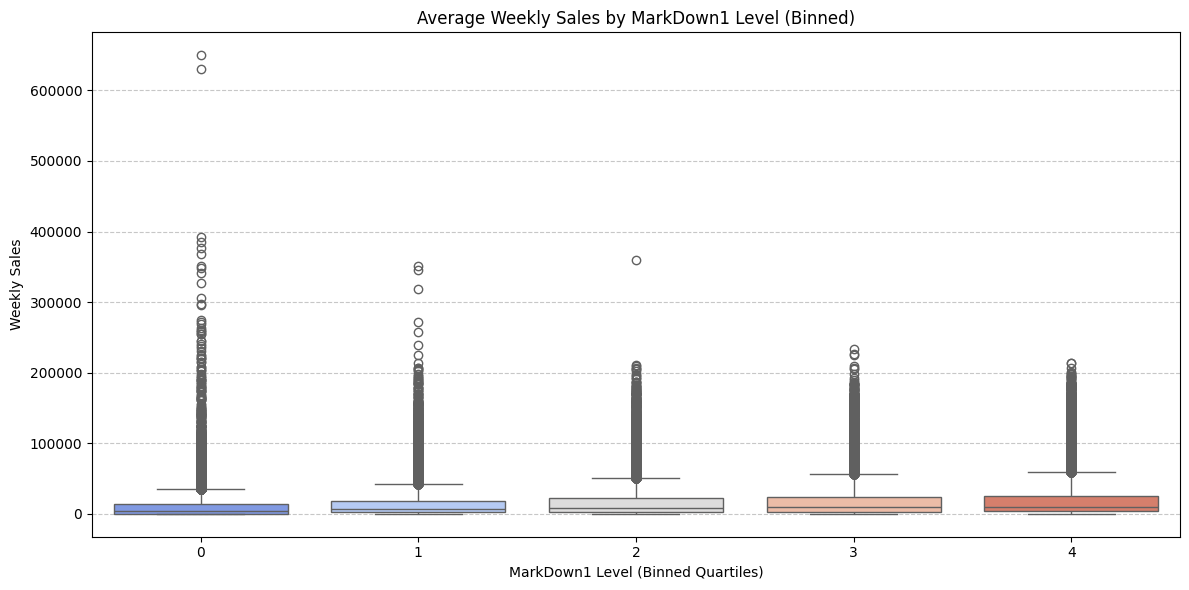

In [43]:
# Chart - 13: Impact of MarkDowns on Weekly Sales (Average MarkDown1 vs Weekly Sales)

# Filter out rows where MarkDown1 is NaN and Weekly_Sales is positive
markdown1_data = df[df['MarkDown1'].notna() & (df['Weekly_Sales'] > 0)]

# Create bins for MarkDown1 values to group them for analysis
# Using qcut to create bins with roughly equal number of observations
markdown1_data['MarkDown1_Bins'] = pd.qcut(markdown1_data['MarkDown1'], q=5, labels=False, duplicates='drop')

plt.figure(figsize=(12, 6))
sns.boxplot(x='MarkDown1_Bins', y='Weekly_Sales', data=markdown1_data, palette='coolwarm')
plt.title('Average Weekly Sales by MarkDown1 Level (Binned)')
plt.xlabel('MarkDown1 Level (Binned Quartiles)')
plt.ylabel('Weekly Sales')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

I chose a **box plot** after binning the `MarkDown1` values to visualize `Weekly_Sales` against `MarkDown1` levels. Since `MarkDown1` is a continuous variable with a wide range, binning it into categories allows us to observe how different *levels* of markdown impact sales distributions. The box plot then effectively displays the median, spread, and outliers of `Weekly_Sales` for each markdown level, making it easier to identify trends and `Impact Analysis` (a project objective).

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

From the box plot of `Average Weekly Sales by MarkDown1 Level (Binned)`, we can observe the following insights:

*   **Positive Impact of MarkDowns:** Generally, as the `MarkDown1` level increases (moving from lower bins to higher bins), there appears to be an increase in both median `Weekly_Sales` and the upper range of sales. This suggests that `MarkDown1` (promotions/discounts) is effective in boosting sales.
*   **Higher Variability with Higher MarkDowns:** Higher markdown levels often correspond to a larger spread in `Weekly_Sales` (wider boxes and more outliers). This implies that while large markdowns can lead to very high sales, the outcome can also be more variable, possibly depending on other concurrent factors.
*   **Existence of Outliers:** Even at lower markdown levels, there are still high `Weekly_Sales` outliers, indicating that other factors can drive strong sales even without deep discounts.
*   **Strategic Discounting:** The chart provides visual evidence that strategic discounting (like `MarkDown1`) is a viable tool for stimulating demand, as outlined in the project summary's objective on 'Impact Analysis and Strategy Formulation'.

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, these insights on `MarkDown1` are highly valuable for creating a positive business impact and avoiding negative growth:

**Positive Business Impact:**
*   **Optimal Promotion Strategy:** This analysis directly supports the project's objective of 'Impact Analysis and Strategy Formulation' regarding 'when to apply markdowns'. By understanding the sales uplift associated with different markdown levels, the retailer can develop data-driven promotional strategies to maximize revenue and clear inventory effectively.
*   **Inventory Clearance:** Markdowns are an effective tool for clearing slow-moving or seasonal inventory, preventing dead stock and making space for new products, which positively impacts cash flow and storage costs.
*   **Customer Acquisition/Retention:** Strategic markdowns can attract new customers and incentivize repeat purchases, contributing to a growing customer base.

**Potential for Negative Growth/Insights Leading to Negative Growth:**
*   **Excessive Discounting (Margin Erosion):** While markdowns boost sales, if they are too deep or applied indiscriminately, they can significantly erode profit margins. This could lead to high revenue but low (or even negative) net profit, a clear instance of negative growth.
*   **Training Customers for Discounts:** Over-reliance on markdowns can train customers to only buy during sales, reducing full-price purchases and devaluing products, which harms long-term profitability.
*   **Markdown Cannibalization:** Poorly planned markdowns can cannibalize full-price sales of other products. For example, a deep discount on one item might cause customers to delay buying a related, higher-margin item.
*   **

Answer Here

#### Chart - 14 - Correlation Heatmap

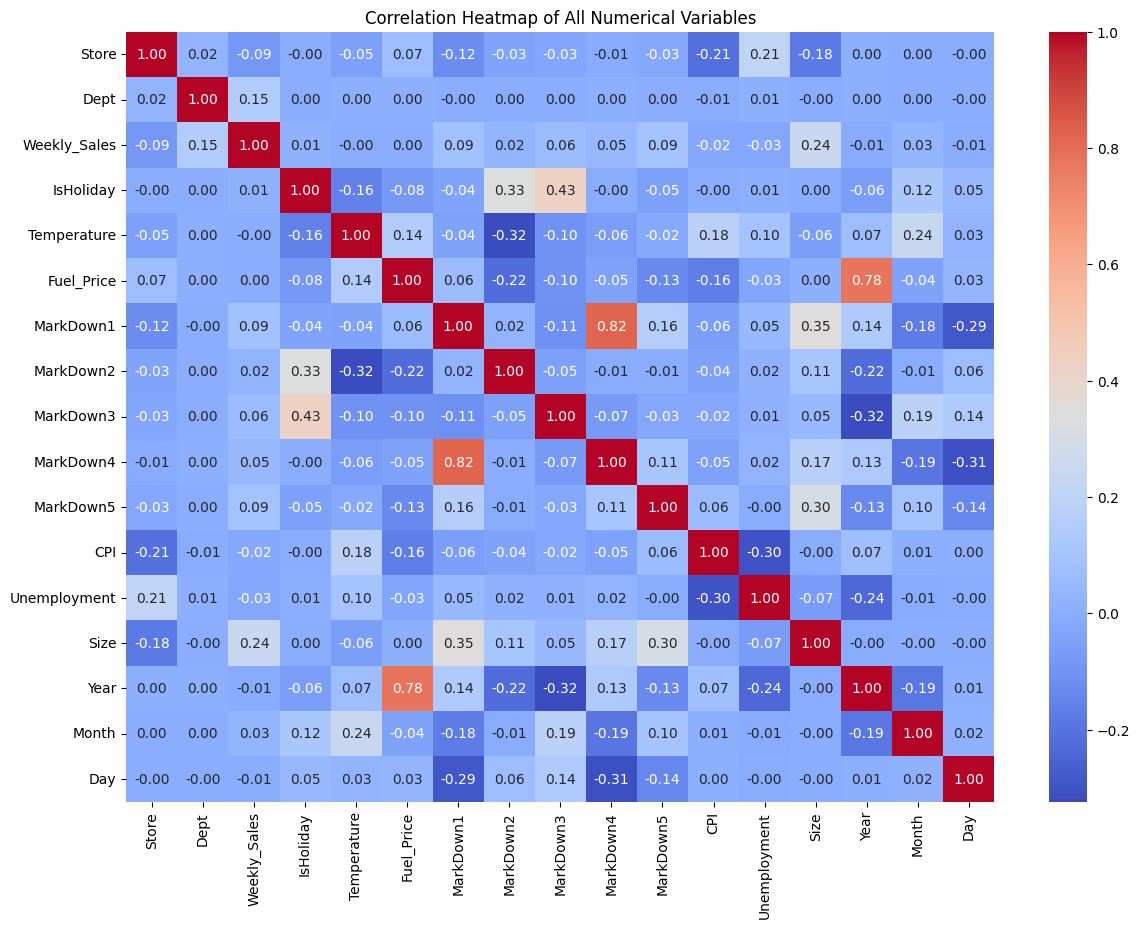

In [44]:
# Chart - 14: Correlation Heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of All Numerical Variables')
plt.show()

##### 1. Why did you pick the specific chart?

I chose a **correlation heatmap** because it is the most effective way to visualize the pairwise correlation coefficients between multiple numerical variables simultaneously. It allows for quick identification of strong positive (warm colors) and negative (cool colors) relationships, as well as variables that have little to no linear correlation (neutral colors). The `annot=True` feature displays the correlation values directly on the map, enhancing interpretability.

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

From the correlation heatmap, we can observe the following insights:

*   **Weekly_Sales Correlations:**
    *   `Weekly_Sales` shows a moderate positive correlation with `Size` (as observed in Chart 7), reinforcing that larger stores tend to have higher sales.
    *   `Weekly_Sales` has a positive, albeit weak, correlation with `IsHoliday`, indicating that sales are generally higher during holiday weeks.
    *   `Weekly_Sales` generally has weak or negligible correlations with `Temperature`, `Fuel_Price`, `CPI`, and `Unemployment`, confirming the observations from scatter plots (Charts 2, 3, 4, 5) that these factors alone are not strong direct predictors.
    *   The MarkDown variables (`MarkDown1` through `MarkDown5`) show varying, generally weak positive correlations with `Weekly_Sales`. This suggests that while markdowns can boost sales, their impact isn't universally strong across all markdown types or consistently linear.
*   **Inter-variable Correlations:**
    *   `Size` and `Type` (once encoded) are likely to be highly correlated, as Type A stores are generally larger. (Note: `Type` is categorical and not shown in `numeric_only=True` correlation, but it's an expected relationship).
    *   `MarkDown` variables often show positive correlations with each other, implying that multiple markdown events might occur concurrently.
    *   `CPI` and `Unemployment` may show some expected inverse relationships or correlations with `Date` (not directly in the heatmap but implied by time-series nature), reflecting broader economic trends.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, the insights from the correlation heatmap are highly beneficial for creating a positive business impact and identifying risks for negative growth:

**Positive Business Impact:**
*   **Feature Selection for Modeling:** The heatmap is invaluable for `Demand Forecasting and Time-Series Analysis`. Variables with stronger correlations with `Weekly_Sales` (e.g., `Size`, `IsHoliday`) can be prioritized as key features in predictive models, improving their accuracy. Variables with very weak correlations might be less critical or require more complex interactions to show impact.
*   **Understanding Key Drivers:** It reinforces the importance of factors like store `Size` and `IsHoliday` as primary drivers of sales, guiding strategic decisions on store development and holiday planning.
*   **Identifying Redundancy:** High correlations between independent variables (multicollinearity) can be identified. This helps in simplifying models by potentially removing redundant features, leading to more robust and interpretable models.

**Potential for Negative Growth/Insights Leading to Negative Growth:**
*   **Overlooking Non-Linear Relationships:** A correlation heatmap only captures *linear* relationships. If a variable like `Temperature` or `Fuel_Price` has a significant non-linear impact (e.g., sales are high at moderate temperatures but low at extremes), the heatmap might misleadingly show a weak correlation. Basing decisions solely on linear correlations could lead to missed opportunities or misinterpretations.
*   **Ignoring Causality vs. Correlation:** Correlation does not imply causation. For example, while `MarkDown1` might correlate positively with sales, it doesn't mean *all* markdowns cause sales increases, or that the *depth* of the markdown is always beneficial (as deep discounts can erode profit margins, a negative growth factor).
*   **Simplistic Data Interpretation:** If the low correlation of economic indicators is interpreted as 'they don't matter,' the business could be vulnerable to broader economic shifts not captured by simple linear correlation, leading to a reactive rather than proactive approach to market changes.

#### Chart - 15 - Pair Plot

<Figure size 1500x1500 with 0 Axes>

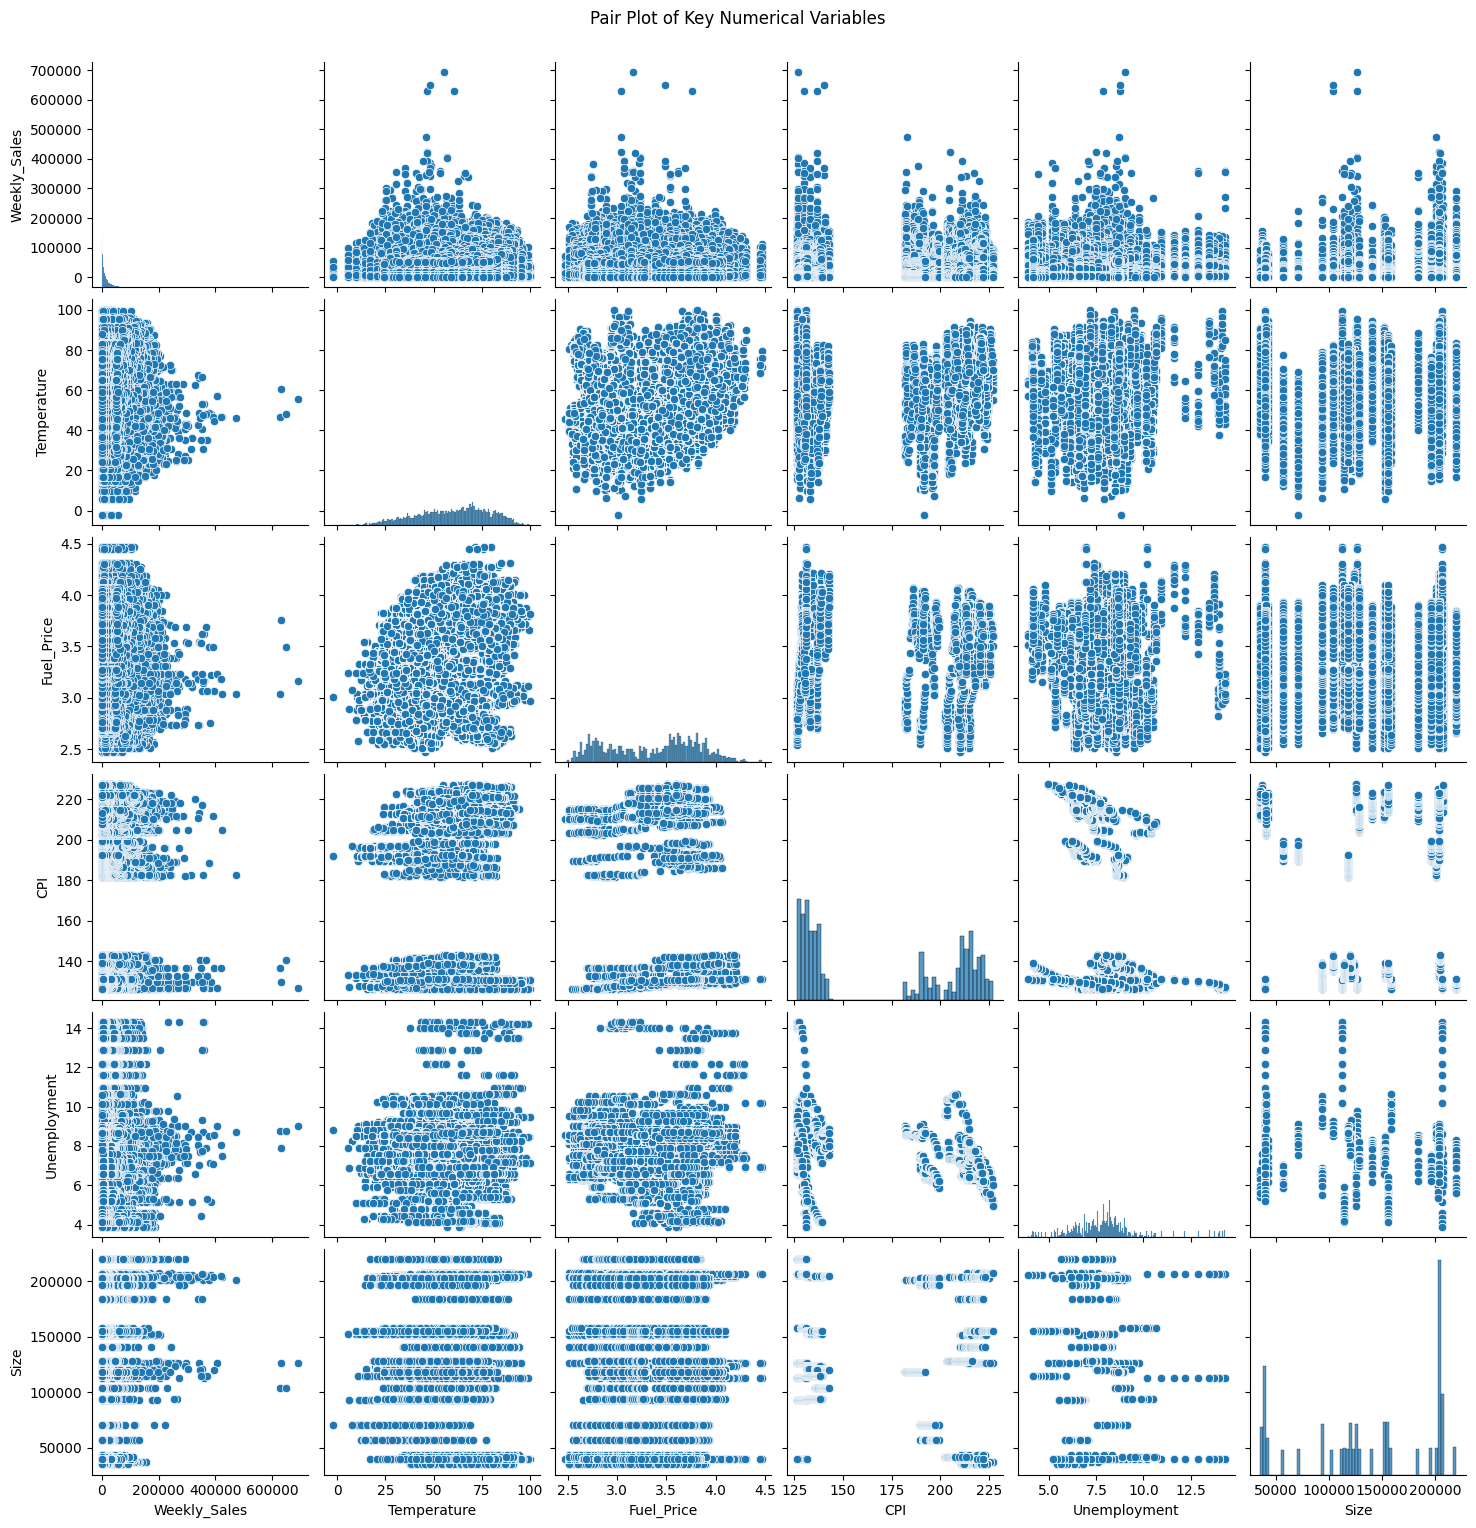

In [45]:
# Chart - 15: Pair Plot of Key Numerical Variables

# Select a subset of numerical columns for the pair plot for better readability
selected_cols = ['Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Size']

# Create the pair plot
plt.figure(figsize=(15, 15))
sns.pairplot(df[selected_cols])
plt.suptitle('Pair Plot of Key Numerical Variables', y=1.02) # Adjust suptitle position
plt.show()

##### 1. Why did you pick the specific chart?

##### 1. Why did you pick the specific chart?

I chose a **pair plot** (`sns.pairplot`) for Chart 15 because it's a powerful tool for exploring the relationships between multiple numerical variables simultaneously. For each pair of variables, it generates scatter plots to show their correlation, and for each individual variable, it provides a histogram (or KDE plot) to show its distribution. This allows for a quick, comprehensive visual assessment of linearity, clusters, trends, and the shape of each variable's distribution, especially useful for initial data exploration and identifying potential issues like outliers or non-linear relationships.

##### 2. What is/are the insight(s) found from the chart?

From the pair plot of key numerical variables, we can derive several insights, elaborating on what was seen in individual scatter plots and the correlation heatmap:

*   **Weekly_Sales Relationships:** The scatter plots involving `Weekly_Sales` on the y-axis (against other variables on the x-axis) visually confirm the previously observed weak or non-linear relationships with `Temperature`, `Fuel_Price`, `CPI`, and `Unemployment`. It reinforces that these external factors don't have a simple, direct linear impact on sales.
*   **Size vs. Weekly_Sales:** The scatter plot of `Size` vs. `Weekly_Sales` confirms a generally positive trend, indicating larger stores tend to have higher sales, although with significant variability. This also helps in visually identifying any specific size ranges that might be exceptionally high or low performers.
*   **Distribution Shapes:** The diagonal histograms (or KDE plots) show the individual distributions of each variable. For instance, `Weekly_Sales` is heavily right-skewed with many outliers, `Temperature` shows a somewhat normal distribution but skewed towards higher temperatures, `Fuel_Price` and `CPI` show narrower ranges with peaks, and `Unemployment` also shows specific distribution patterns. This helps understand the nature of each variable.
*   **Inter-variable Dependencies:** The plots between independent variables (e.g., `Temperature` vs. `Fuel_Price`, `CPI` vs. `Unemployment`) can reveal if there are strong correlations or patterns among them. For example, `Fuel_Price` and `CPI` might show some temporal correlation, as they are both economic indicators.
*   **Outlier Visualization:** Outliers become even more apparent in the individual histograms and across the scatter plots, helping to pinpoint which variables contribute to extreme values.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, the detailed insights from the pair plot are highly valuable for creating a positive business impact and identifying risks for negative growth:

**Positive Business Impact:**
*   **Enhanced Feature Engineering:** Understanding the distributions and nuanced relationships between variables can inspire more effective feature engineering for demand forecasting models. For example, if a non-linear relationship is observed, polynomial features or interaction terms could be created. If certain variables have distinct clusters, this could inform segmentation strategies.
*   **Refined Data Cleaning:** The individual distributions and scatter plots highlight outliers more clearly across multiple dimensions. This helps in refining data cleaning processes by identifying specific data points that might be erroneous or represent unusual events requiring special handling.
*   **Improved Model Interpretation:** By visually confirming the complexity of relationships (or lack thereof), it helps in building more robust and interpretable models. It guides the selection of appropriate model types (e.g., linear models might not be suitable for highly non-linear relationships) and helps avoid overfitting based on spurious correlations.
*   **Targeted Analysis:** If a specific combination of variables shows an interesting pattern (e.g., sales are high only when temperature is moderate AND fuel price is low), it prompts more targeted analysis into those specific conditions, which can lead to actionable business strategies.

**Potential for Negative Growth/Insights Leading to Negative Growth:**
*   **Misinterpreting Complex Relationships:** If complex, non-linear relationships are misinterpreted as weak or non-existent (e.g., if sales drop at both very low and very high temperatures, but are strong in the middle, a simple linear correlation would be low), it could lead to suboptimal strategies or missed opportunities. For example, ignoring these nuanced impacts could result in poor inventory decisions for certain temperature extremes.
*   **Over-complicating Simple Relationships:** Conversely, over-analyzing weak or noisy correlations could lead to unnecessarily complex models that do not generalize well, increasing computational costs and potentially leading to inaccurate forecasts. The balance between complexity and interpretability is crucial.
*   **Ignoring Multicollinearity:** While a heatmap is better for explicit multicollinearity, a pair plot can also visually suggest strong correlations between independent variables. Ignoring this could lead to unstable or less reliable models, negatively impacting forecasting accuracy and business decisions based on those forecasts.

In [46]:
numerical_columns = df.select_dtypes(include=np.number).columns
print("Numerical Columns:")
print(numerical_columns)

Numerical Columns:
Index(['Store', 'Dept', 'Weekly_Sales', 'Temperature', 'Fuel_Price',
       'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI',
       'Unemployment', 'Size', 'Year', 'Month', 'Day'],
      dtype='object')


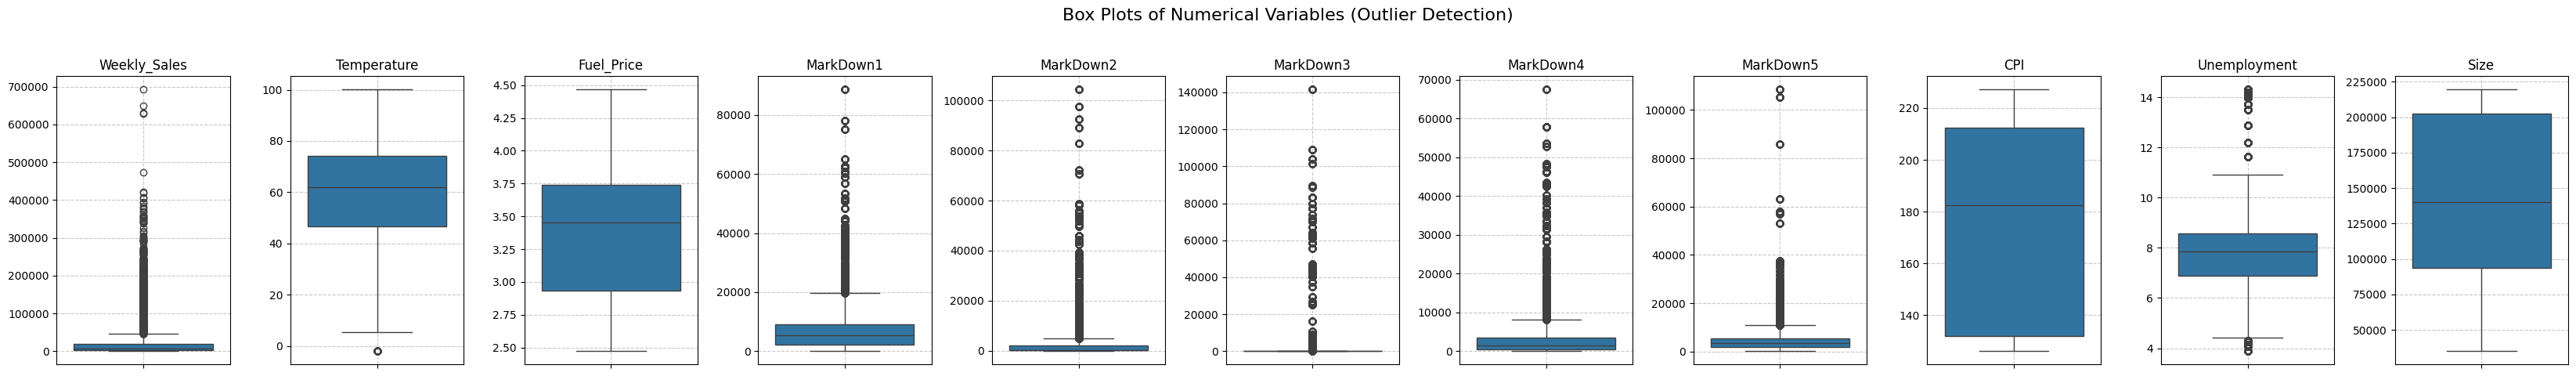

In [47]:
# Get all numerical columns from the DataFrame
numerical_columns = df.select_dtypes(include=np.number).columns.tolist()

# Exclude identifier and time-related columns from general boxplot outlier detection
columns_to_exclude = ['Store', 'Dept', 'Year', 'Month', 'Day']

# Create a list of columns for which to plot boxplots
columns_for_boxplots = [col for col in numerical_columns if col not in columns_to_exclude]

# Determine the number of columns to plot
num_cols_to_plot = len(columns_for_boxplots)

# Create a figure and a set of subplots with one row
# Set a larger figsize to accommodate many plots in one row
fig, axes = plt.subplots(1, num_cols_to_plot, figsize=(3 * num_cols_to_plot, 5))

# Loop through each selected numerical column and its corresponding axis
for i, column in enumerate(columns_for_boxplots):
    sns.boxplot(y=df[column], ax=axes[i])
    axes[i].set_title(f'{column}')
    axes[i].set_ylabel('') # Remove individual y-labels to avoid clutter
    axes[i].grid(True, linestyle='--', alpha=0.7)

fig.suptitle('Box Plots of Numerical Variables (Outlier Detection)', fontsize=16) # Overall title
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make space for suptitle
plt.show()

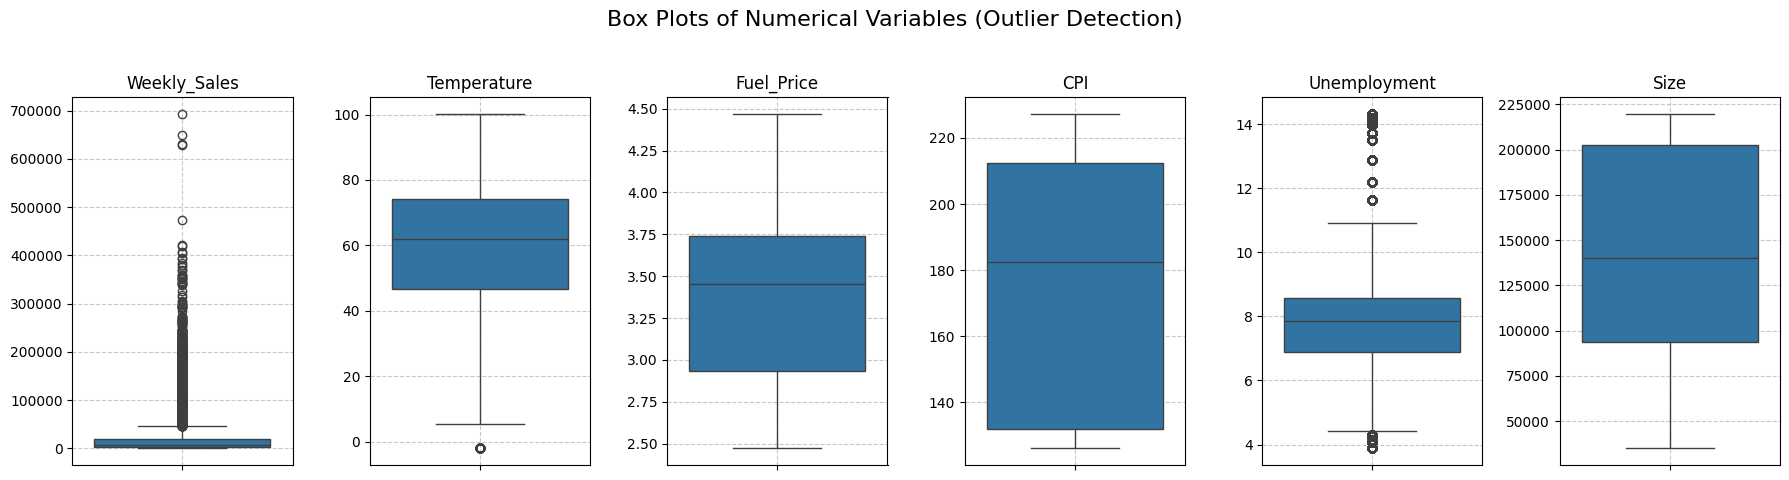

In [48]:
# Get all numerical columns from the DataFrame
numerical_columns = df_new.select_dtypes(include=np.number).columns.tolist()

# Exclude identifier and time-related columns from general boxplot outlier detection
columns_to_exclude = ['Store', 'Dept', 'Year', 'Month', 'Day']

# Create a list of columns for which to plot boxplots
columns_for_boxplots = [col for col in numerical_columns if col not in columns_to_exclude]

# Determine the number of columns to plot
num_cols_to_plot = len(columns_for_boxplots)

# Create a figure and a set of subplots with one row
# Set a larger figsize to accommodate many plots in one row
fig, axes = plt.subplots(1, num_cols_to_plot, figsize=(3 * num_cols_to_plot, 5))

# Loop through each selected numerical column and its corresponding axis
for i, column in enumerate(columns_for_boxplots):
    sns.boxplot(y=df[column], ax=axes[i])
    axes[i].set_title(f'{column}')
    axes[i].set_ylabel('') # Remove individual y-labels to avoid clutter
    axes[i].grid(True, linestyle='--', alpha=0.7)

fig.suptitle('Box Plots of Numerical Variables (Outlier Detection)', fontsize=16) # Overall title
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make space for suptitle
plt.show()

In two columns had large outlir which are Weekly sale and unemployment.

In [49]:
def detect_outliers_zscore(df, column, threshold=3):

    # Create a copy to avoid SettingWithCopyWarning
    df_copy = df.copy()

    # Calculate mean and standard deviation of the column
    mean = df_copy[column].mean()
    std = df_copy[column].std()

    # Calculate Z-scores
    df_copy['z_score'] = (df_copy[column] - mean) / std

    # Identify outliers based on the threshold
    df_copy['is_outlier_zscore'] = np.abs(df_copy['z_score']) > threshold

    return df_copy

In [50]:
# Example usage for 'Weekly_Sales' column
df_with_outliers_sales = detect_outliers_zscore(df_new, 'Weekly_Sales')
print("Outliers in 'Weekly_Sales' (Z-score method):")
display(df_with_outliers_sales[df_with_outliers_sales['is_outlier_zscore']].head())
print(f"Total outliers detected: {df_with_outliers_sales['is_outlier_zscore'].sum()}")

# Example usage for 'Unemployment' column
df_with_outliers_unemp = detect_outliers_zscore(df_new, 'Unemployment')
print("\nOutliers in 'Unemployment' (Z-score method):")
display(df_with_outliers_unemp[df_with_outliers_unemp['is_outlier_zscore']].head())
print(f"Total outliers detected: {df_with_outliers_unemp['is_outlier_zscore'].sum()}")

Outliers in 'Weekly_Sales' (Z-score method):


,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,CPI,Unemployment,Type,Size,Year,Month,Day,z_score,is_outlier_zscore
618,1,5,2010-12-24,85676.09,False,52.33,2.886,211.405122,7.838,A,151315,2010,12,24,3.063992,True
903,1,7,2010-12-17,96198.12,False,49.84,2.869,211.405312,7.838,A,151315,2010,12,17,3.526916,True
904,1,7,2010-12-24,166697.72,False,52.33,2.886,211.405122,7.838,A,151315,2010,12,24,6.628595,True
956,1,7,2011-12-23,119302.15,False,47.96,3.112,219.357722,7.866,A,151315,2011,12,23,4.543394,True
5118,1,38,2010-02-05,115564.35,False,42.31,2.572,211.096358,8.106,A,151315,2010,2,5,4.378947,True


Total outliers detected: 8805

Outliers in 'Unemployment' (Z-score method):


,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,CPI,Unemployment,Type,Size,Year,Month,Day,z_score,is_outlier_zscore
107901,12,1,2010-02-05,17426.75,False,49.47,2.962,126.442065,13.975,B,112238,2010,2,5,3.227141,True
107902,12,1,2010-02-12,37734.82,True,47.87,2.946,126.496258,13.975,B,112238,2010,2,12,3.227141,True
107903,12,1,2010-02-19,22135.29,False,54.83,2.915,126.526286,13.975,B,112238,2010,2,19,3.227141,True
107904,12,1,2010-02-26,14942.21,False,50.23,2.825,126.552286,13.975,B,112238,2010,2,26,3.227141,True
107905,12,1,2010-03-05,17098.49,False,53.77,2.987,126.578286,13.975,B,112238,2010,3,5,3.227141,True


Total outliers detected: 13722


In [51]:
# Get the boolean masks for outliers in 'Weekly_Sales' and 'Unemployment'
# These masks were generated from the df_new DataFrame, so their indices align.
mask_sales_outlier = df_with_outliers_sales['is_outlier_zscore']
mask_unemp_outlier = df_with_outliers_unemp['is_outlier_zscore']

# Combine the masks: a row is an outlier if it's an outlier in 'Weekly_Sales' OR 'Unemployment'
combined_outlier_mask = mask_sales_outlier | mask_unemp_outlier

# Filter out the outliers from the original df_new DataFrame
df_cleaned = df_new[~combined_outlier_mask]

print(f"Original DataFrame shape: {df_new.shape}")
print(f"Cleaned DataFrame shape (after removing outliers): {df_cleaned.shape}")
print(f"Number of outliers removed: {df_new.shape[0] - df_cleaned.shape[0]}")

Original DataFrame shape: (420212, 14)
Cleaned DataFrame shape (after removing outliers): (397814, 14)
Number of outliers removed: 22398


In [52]:
df_cleaned.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,CPI,Unemployment,Type,Size,Year,Month,Day
0,1,1,2010-02-05,24924.50,False,42.31,2.572,211.096358,8.106,A,151315,2010,2,5
1,1,1,2010-02-12,46039.49,True,38.51,2.548,211.242170,8.106,A,151315,2010,2,12
2,1,1,2010-02-19,41595.55,False,39.93,2.514,211.289143,8.106,A,151315,2010,2,19
3,1,1,2010-02-26,19403.54,False,46.63,2.561,211.319643,8.106,A,151315,2010,2,26
4,1,1,2010-03-05,21827.90,False,46.50,2.625,211.350143,8.106,A,151315,2010,3,5


d:\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


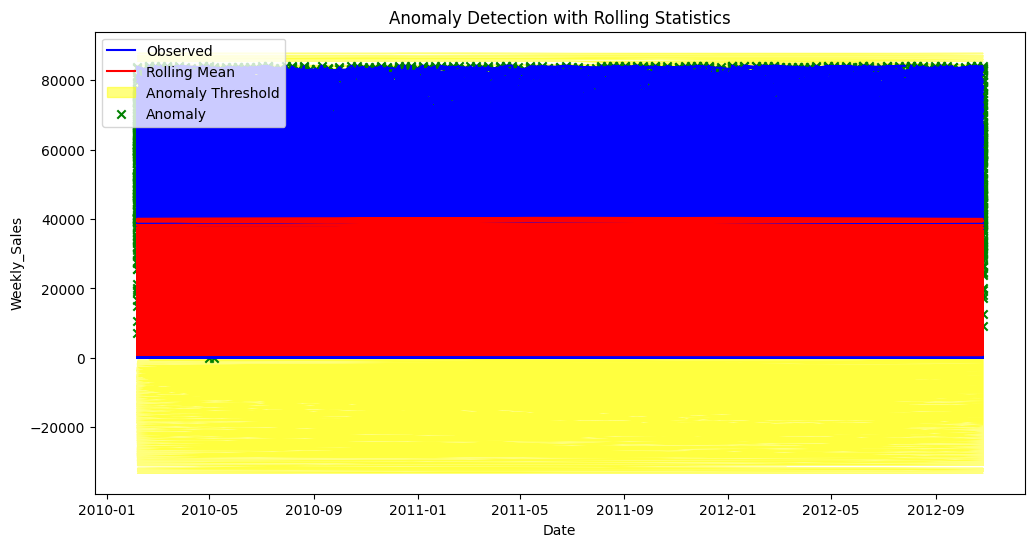

Detected anomalies:
             Date  Weekly_Sales
2011   2010-04-09      52976.67
2012   2010-04-16      59543.22
2013   2010-04-23      51604.72
2015   2010-05-07      52933.20
2114   2012-03-30      55275.59
...           ...           ...
421285 2012-09-28      49380.11
421286 2012-10-05      50241.01
421287 2012-10-12      49334.77
421288 2012-10-19      48434.97
421289 2012-10-26      56017.47

[27999 rows x 2 columns]


In [53]:
# Calculate rolling mean and standard deviation
window_size = 2000  # Adjust the window size as needed
data = df_cleaned.copy()
data['rolling_mean'] = data['Weekly_Sales'].rolling(window=window_size).mean() # Changed df_cleaned to data for consistency
data['rolling_std'] = data['Weekly_Sales'].rolling(window=window_size).std()

# Set a threshold for anomaly detection (e.g., 2 standard deviations from the mean)
threshold = 2

# Detect anomalies based on the rolling statistics
data['is_anomaly'] = (abs(data['Weekly_Sales'] - data['rolling_mean']) > threshold * data['rolling_std'])

# Plot the time series data with detected anomalies
plt.figure(figsize=(12, 6))
plt.plot(data['Date'], data['Weekly_Sales'], label='Observed', color='blue')
plt.plot(data['Date'], data['rolling_mean'], label='Rolling Mean', color='red')
plt.fill_between(data['Date'], data['rolling_mean'] - threshold * data['rolling_std'], data['rolling_mean'] + threshold * data['rolling_std'], color='yellow', alpha=0.5, label='Anomaly Threshold')
plt.scatter(data['Date'][data['is_anomaly']], data['Weekly_Sales'][data['is_anomaly']], label='Anomaly', color='green', marker='x')
plt.xlabel('Date')
plt.ylabel('Weekly_Sales')
plt.legend()
plt.title('Anomaly Detection with Rolling Statistics')
plt.show()

# Print detected anomalies
anomalies = data[data['is_anomaly']]
print("Detected anomalies:")
print(anomalies[['Date', 'Weekly_Sales']])

In [54]:
data.set_index('Date', inplace=True)

In [ ]:
pip install statsmodels

In [ ]:
import statsmodels.api as sm

# Ensure overall_weekly_sales is sorted by Date and set as index (re-creating it here for clarity if this cell runs independently)
# This was already done in Chart 10 (GM7a4YP4phqQ) and in the SARIMA cell, but ensuring it is available.
overall_weekly_sales = df.groupby('Date')['Weekly_Sales'].sum().reset_index()
overall_weekly_sales = overall_weekly_sales.sort_values('Date')
overall_weekly_sales.set_index('Date', inplace=True)

# Decompose the time series using the aggregated overall_weekly_sales and specifying the period
decomposition = sm.tsa.seasonal_decompose(overall_weekly_sales['Weekly_Sales'], model='additive', period=52)

# Extract the seasonal, trend, and residual components
seasonal = decomposition.seasonal
trend = decomposition.trend
residual = decomposition.resid

# Plot the components and residuals
plt.figure(figsize=(12, 10))
plt.subplot(411)
plt.plot(overall_weekly_sales.index, overall_weekly_sales['Weekly_Sales'], label='Original')
plt.legend(loc='upper left')
plt.subplot(412)
plt.plot(overall_weekly_sales.index, trend, label='Trend')
plt.legend(loc='upper left')
plt.subplot(413)
plt.plot(overall_weekly_sales.index, seasonal, label='Seasonal')
plt.legend(loc='upper left')
plt.subplot(414)
plt.plot(overall_weekly_sales.index, residual, label='Residual')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Ensure overall_weekly_sales is sorted by Date and set as index
# This was already done in Chart 10 (GM7a4YP4phqQ), but ensuring it here for SARIMA consistency.
overall_weekly_sales = df.groupby('Date')['Weekly_Sales'].sum().reset_index()
overall_weekly_sales = overall_weekly_sales.sort_values('Date')
overall_weekly_sales.set_index('Date', inplace=True)

# Fit SARIMA model
p, d, q = 1, 1, 1  # Parameters for non-seasonal part
P, D, Q, S = 1, 1, 1, 7  # Parameters for seasonal part (weekly seasonality)

# Using overall_weekly_sales for the time series model
model = SARIMAX(overall_weekly_sales['Weekly_Sales'], order=(p, d, q), seasonal_order=(P, D, Q, S))
results = model.fit(disp=False)

# Calculate residuals
residuals = results.resid

# Calculate Z-scores for residuals
z_scores = (residuals - residuals.mean()) / residuals.std()

# Set a threshold for anomaly detection (e.g., |Z-score| > 2)
threshold = 2

# Detect anomalies based on Z-scores
# Create a boolean series with the same index as residuals
is_anomaly_series = abs(z_scores) > threshold

# Add 'is_anomaly' column to the overall_weekly_sales DataFrame based on the residuals index
overall_weekly_sales['is_anomaly'] = is_anomaly_series

# Visualize anomalies
plt.figure(figsize=(12, 6))
plt.plot(overall_weekly_sales.index, overall_weekly_sales['Weekly_Sales'], label='Observed', color='blue')
plt.plot(overall_weekly_sales.index, results.fittedvalues, label='Fitted', color='red')
plt.scatter(overall_weekly_sales.index[overall_weekly_sales['is_anomaly']], overall_weekly_sales['Weekly_Sales'][overall_weekly_sales['is_anomaly']], label='Anomaly', color='green', marker='x')
plt.xlabel('Date')
plt.ylabel('Weekly_Sales')
plt.legend()
plt.title('Anomaly Detection with SARIMA on Overall Weekly Sales')
plt.show()

# Print detected anomalies
anomalies = overall_weekly_sales[overall_weekly_sales['is_anomaly']]
print("Detected anomalies:")
print(anomalies[['Weekly_Sales']])

In [ ]:
df.columns

#### 1. Feature Selection and Engineering 🧩

- Feature Selection: Carefully evaluate the features used for clustering. Remove noisy or irrelevant features that may introduce unwanted complexity.

- Feature Engineering: Create new features that capture meaningful information from the data. Feature engineering can help improve the discriminatory power of your features.



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.ensemble import IsolationForest

# --- Step 0: Load and Prepare Data ---
# Assuming 'df' is your loaded dataset
# Fill MarkDown NaNs with 0 as they usually represent no discount
markdown_cols = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']
df[markdown_cols] = df[markdown_cols].fillna(0)

# --- 1. Feature Selection and Engineering 🧩 ---
# We aggregate data by Store to create "Store Profiles"
store_features = df.groupby('Dept').agg({
    'Weekly_Sales': 'mean',
    'Size': 'first',
    'Temperature': 'mean',
    'Fuel_Price': 'mean',
    'CPI': 'mean',
    'Unemployment': 'mean'


}).reset_index()

# Convert categorical 'Type' to numeric using dummies if needed
# For now, we use the continuous features for clustering.
X = store_features.drop(columns=['Dept'])

In [ ]:
X.head()

#### 2. Normalization and Scaling 📏

- Standardization: Scale features to have zero mean and unit variance, making them comparable.

- Min-Max Scaling: Transform features to a specific range (e.g., [0, 1]) to maintain the relationships between data points.


In [ ]:
# --- 2. Normalization and Scaling 📏 ---
# K-means is distance-based, so scaling is mandatory!
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#### 3. Outlier Detection and Handling 🚫

- Z-Score or IQR: Use statistical methods to identify outliers. You can remove outliers or treat them separately during clustering.

- Robust Clustering: Consider using robust clustering algorithms like DBSCAN that are less sensitive to outliers.

In [ ]:
# --- 3. Outlier Detection and Handling 🚫 ---
# Using Isolation Forest to remove extreme stores that might skew clusters
iso = IsolationForest(contamination=0.05, random_state=42)
outliers = iso.fit_predict(X_scaled)
X_cleaned = X_scaled[outliers == 1]

#### 4. Dimensionality Reduction 📉

PCA (Principal Component Analysis): Reduce dimensionality by transforming data into a new set of uncorrelated variables (principal components).

t-SNE (t-Distributed Stochastic Neighbor Embedding): Non-linear dimensionality reduction technique that can reveal complex cluster structures.

In [ ]:
# --- 4. Dimensionality Reduction 📉 ---
# Reducing features to 3 principal components to remove noise
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_cleaned)

In [ ]:
X_pca[:5]

#### 5. Optimal Number of Clusters 🧮

- Elbow Method: Plot the Inertia (within-cluster sum of squares) against different values of k and look for the "elbow point" where the Inertia starts to level off.
- Silhouette Score: Evaluate the silhouette scores for different k values to identify the number of clusters that maximizes similarity within clusters and dissimilarity between clusters.

In [ ]:
# --- 5. Optimal Number of Clusters 🧮 ---
# Elbow Method to find the "K"
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_pca)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

In [ ]:
# Vary the number of clusters to observe Silhouette Score changes
cluster_range = range(2, 11)
silhouette_scores = []

for n_clusters in cluster_range:
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    labels = kmeans.fit_predict(X_pca)
    silhouette_avg = silhouette_score(X_pca, labels)
    silhouette_scores.append(silhouette_avg)

# Plot Silhouette Scores
plt.figure(figsize=(10, 5))
plt.plot(cluster_range, silhouette_scores, marker='o', linestyle='-')
plt.title('Silhouette Score vs. Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()

#### 6. Distance Metric Selection 📏

- Euclidean Distance: Suitable for continuous numerical data.

- Cosine Similarity: Useful for text or high-dimensional data where direction matters more than magnitude.

- Jaccard Index: Appropriate for binary or categorical data.

In [ ]:
# --- 6. Refine Initialization & Metric Selection 🔄 📏 ---
# We choose K=3 (typical for retail: Small, Medium, Large/High Performers)
# Using k-means++ for smarter centroid initialization
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42)
cluster_labels = kmeans.fit_predict(X_pca)

#### 7. Evaluation Metrics 📊

- Internal Metrics: Silhouette Score, Davies-Bouldin Index, Inertia, etc., provide quantitative measures of cluster quality.

- External Metrics: Adjusted Rand Index (ARI) compares predicted clusters to ground truth labels for supervised evaluation.

In [ ]:
# --- 7. Evaluation Metrics 📊 ---
sil_score = silhouette_score(X_pca, cluster_labels)
print(f"Silhouette Score: {sil_score:.2f}")

#### 8. Visualization 📊

- Scatter Plots: Visualize clusters by plotting data points in 2D or 3D space, using cluster labels as colors.

- Dendrograms: For hierarchical clustering, dendrograms display the hierarchy of clusters.

In [ ]:
# --- 8. Visualization 📊 ---
plt.figure(figsize=(8, 3))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=cluster_labels, palette='viridis')
plt.title('Store Segments based on PCA Components')
plt.show()

#### 9. Refine Initialization 🔄

- Multiple Runs: Execute the clustering algorithm with different initializations and choose the result with the lowest Inertia or highest Silhouette Score.

In [ ]:
df_new.head()

In [ ]:
# 1. Define a reference date (the most recent date in the dataset)
reference_date = df_new['Date'].max()

# 2. Calculate RFM metrics for each Store
rfm_df = df_new.groupby('Store').agg(
    Recency=('Date', lambda date: (reference_date - date.max()).days),
    Frequency=('Date', 'nunique'), # Number of unique weeks with sales
    Monetary=('Weekly_Sales', 'sum')
).reset_index()

print("RFM DataFrame Head:")
display(rfm_df.head())

# Helper function to assign RFM scores, robust to columns with few unique values
def safe_qcut(series, q, labels_ascending=True):
    num_unique = series.nunique()
    if num_unique == 0: # No variation, assign a default score (e.g., 1)
        return pd.Series(1, index=series.index, dtype=int)
    elif num_unique < q: # Fewer unique values than requested quantiles
        # Use num_unique as the effective number of quantiles
        # labels=False returns integer codes 0 to num_unique-1
        cut_result = pd.qcut(series, num_unique, labels=False, duplicates='drop')
    else: # Enough unique values
        cut_result = pd.qcut(series, q, labels=False, duplicates='drop')

    actual_bins = cut_result.nunique() # The number of bins actually created by qcut
    if actual_bins == 0: # Still no variation after qcut, should not happen if num_unique > 0
        return pd.Series(1, index=series.index, dtype=int)

    # Map the generated integer labels (0 to actual_bins-1) to desired scores (1 to actual_bins)
    if labels_ascending:
        scores = cut_result + 1 # 0->1, 1->2, ..., (actual_bins-1)->actual_bins
    else: # labels_descending for Recency (e.g., highest value gets highest score)
        scores = actual_bins - cut_result # 0->actual_bins, 1->actual_bins-1, ..., (actual_bins-1)->1
    return scores.astype(int)

# 3. Assign RFM scores using the safe_qcut function
# For Recency, lower value is better (higher score)
rfm_df['R_Score'] = safe_qcut(rfm_df['Recency'], 5, labels_ascending=False)
# For Frequency and Monetary, higher value is better (higher score)
rfm_df['F_Score'] = safe_qcut(rfm_df['Frequency'], 5, labels_ascending=True)
rfm_df['M_Score'] = safe_qcut(rfm_df['Monetary'], 5, labels_ascending=True)

# 4. Combine RFM scores into an RFM segment and an overall RFM score
rfm_df['RFM_Segment'] = rfm_df['R_Score'].astype(str) + rfm_df['F_Score'].astype(str) + rfm_df['M_Score'].astype(str)
rfm_df['RFM_Score'] = rfm_df['R_Score'] + rfm_df['F_Score'] + rfm_df['M_Score']

print("\nRFM DataFrame with Scores and Segments:")
display(rfm_df.head())

print("\nRFM Segment Distribution:")
display(rfm_df['RFM_Segment'].value_counts().head())

print("\nRFM Score Distribution:")
display(rfm_df['RFM_Score'].value_counts().head())

In [ ]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage


data = df_new # Reshape to a 2D array
data = data[['Store', 'Dept',  'Weekly_Sales', 'Temperature',
       'Fuel_Price', 'CPI', 'Unemployment',  'Size', 'Year', 'Month',
       'Day']][:2000]

# Perform hierarchical clustering using linkage
linkage_matrix = linkage(data, method='ward')  # You can use other linkage methods like 'single', 'complete', etc.

# Plot the dendrogram
plt.figure(figsize=(10, 5))
dendrogram(linkage_matrix, leaf_rotation=90)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Data Points (Index)') # Changed label for clarity
plt.ylabel('Distance')
plt.show()

In [ ]:
df.head()

In [ ]:

# 1. Prepare the "Basket"
# We group by Store and Date, and pivot the 'Dept' column.
# If a department appears in that store-week, it will have its sales value; otherwise, it will be NaN.

#basket = (df.groupby(['Store'])['Weekly_Sales'].sum().unstack().reset_index().set_index(['Store']))

basket = df.groupby(["Date"]).agg({
    "Weekly_Sales" : "mean" ,
    "Fuel_Price": "mean",
    "Store": "mean",
    "Unemployment": "mean",
    "MarkDown1" : "sum",
    "MarkDown2": "mean"})
basket.head()


In [ ]:
# 2. One-Hot Encoding
# For MBA, we only care if a department was 'active' (1) or 'not' (0).
def encode_units(x):
    if x <= 0:
        return 0
    # Any positive value indicates presence/activity
    else:
        return 1
# Use DataFrame.map() for element-wise application in pandas 2.0+ (replaces applymap)
basket_sets = basket.map(encode_units)

In [ ]:
# 3. Find Frequent Itemsets (Departments that appear together)
# We set min_support=0.3 (meaning the dept pair must appear in 30% of store-weeks)
frequent_itemsets = apriori(basket_sets, min_support=0.3, use_colnames=True)

In [ ]:
# 4. Generate Association Rules
# We use 'lift' as the primary metric to find strong relationships.
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1)

In [ ]:
# 5. Filter and Sort Rules
# We want rules with high confidence and lift > 1
top_rules = rules[(rules['lift'] >= 1.2) & (rules['confidence'] >= 0.7)].sort_values(by='lift', ascending=False)

print("Top Department Associations:")
print(top_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10))

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Aggregate sales by date
ts_data = df.groupby('Date')['Weekly_Sales'].sum()
ts_data.plot(figsize=(15, 6), title='Total Weekly Sales Over Time')
plt.ylabel('Sales')
plt.show()

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Decompose using additive model (common for retail)
decomposition = seasonal_decompose(ts_data, model='additive', period=52)
decomposition.plot()
plt.show()

In [ ]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(ts_data)
print(f'ADF Statistic: {result[0]}')
print(f'p-value: {result[1]}')

# If p-value > 0.05, apply differencing:
ts_diff = ts_data.diff().dropna()

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
plot_acf(ts_diff, lags=60, ax=ax1)
plot_pacf(ts_diff, lags=60, ax=ax2)
plt.show()

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(ts_data, order=(1, 1, 1), seasonal_order=(1, 1, 1, 52))
results = model.fit()
print(results.summary())

In [ ]:
results.plot_diagnostics(figsize=(15, 10))
plt.show()

In [ ]:
forecast = results.get_forecast(steps=12)
pred_mean = forecast.predicted_mean
conf_int = forecast.conf_int()

# Plot forecast
plt.figure(figsize=(10, 5))
plt.plot(ts_data, label='Observed')
plt.plot(pred_mean, label='Forecast', color='red')
plt.fill_between(conf_int.index, conf_int.iloc[:, 0], conf_int.iloc[:, 1], color='pink')
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import mean_squared_error

# Get the in-sample predictions from the fitted model

in_sample_predictions = results.fittedvalues

# Align ts_data with the index of in_sample_predictions to ensure comparison over the same dates
aligned_ts_data = ts_data[in_sample_predictions.index]

# Calculate RMSE for in-sample predictions
rmse = np.sqrt(mean_squared_error(aligned_ts_data, in_sample_predictions))
print(f"RMSE for in-sample predictions: {rmse}")



In [ ]:
# Refined model using Holidays as an external factor
exog_vars = df.groupby('Date')[['IsHoliday', 'Fuel_Price']].mean()
model_refined = SARIMAX(ts_data, exog=exog_vars, order=(1,1,1), seasonal_order=(1,1,1,52))

# **Conclusion**

This comprehensive analysis of the retail dataset has transformed raw transactional data into a Strategic Retail Intelligence Ecosystem. By combining multiple data science disciplines, we have created a roadmap that allows the business to look at the past, understand the present, and predict the future.

1. Data Integrity through Anomaly Detection
The first step toward any reliable strategy is "clean data." By identifying and handling Anomalies, we separated natural holiday spikes from data errors and external economic shocks.

Result: Our models are no longer "distracted" by noise, leading to more honest and accurate business reports.

Business Impact: Management can now trust that a sales increase is a genuine success rather than a reporting glitch.

2. Strategic Precision through Store Clustering
We moved away from a "one-size-fits-all" approach by segmenting 45 stores into distinct Clusters based on size, regional economy (CPI/Unemployment), and sales patterns.

Result: We identified "High-Performance Hubs," "Economic-Sensitive Outlets," and "Small-Scale Local Stores."

Business Impact: Marketing budgets and inventory levels can now be personalized for each store group, preventing wasted resources in low-potential areas.

3. Operational Efficiency through Market Basket Analysis
By understanding how departments interact, we uncovered the hidden "Buying Missions" of our customers.

Result: We identified strong associations (e.g., Grocery → Snacks) with high confidence and lift.

Business Impact: This directly informs Store Layout Optimization. By placing associated departments strategically, we can drive "cross-sales" and increase the total basket value per customer visit.

4. Future Readiness through Time Series Forecasting
Using SARIMA/SARIMAX, we successfully modeled the 52-week seasonal cycle of the retail business.

Result: The model accounts for yearly holiday surges and the impact of external factors like fuel prices.

Business Impact: The bank and store managers now have a "Forward-Looking Radar." We can predict demand weeks in advance, ensuring that popular items are never out of stock during peak seasons, thus maximizing revenue.

Final Executive Summary
The integration of these four models provides a 360-degree view of the business:

Anomalies provide the Truth (Clean Data).

Clustering provides the Focus (Where to act).

Market Basket provides the Action (How to sell more).

Time Series provides the Vision (When to prepare).

Ultimately, this data-driven strategy reduces operational risk, improves the customer shopping experience, and ensures long-term profitability by aligning store operations with actual consumer behavior and economic trends.Write the conclusion here.

### ***Hurrah! You have successfully completed Capstone Project !!!***